This is a **CLEAN** but vivid version of codes (along with visualizations) 
for analyzing the experiment ***freight collaboration-chessboard*** results

In [305]:
from dataclasses import dataclass
from enum import Enum
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
# Use repo-relative path so it works on other machines
notebook_dir = Path.cwd() / "python" / "test"
if notebook_dir.exists() and str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))
import matsim
import matsim_output_reader
import metric_anls
import figure_plot 
# --- reload the module to reflect any changes made during development ---
import importlib
importlib.reload(matsim_output_reader)
importlib.reload(metric_anls)
importlib.reload(figure_plot)

<module 'figure_plot' from 'f:\\gitRepository\\matsim-libs-2024\\python\\test\\figure_plot.py'>

# Configuration

In [96]:
# Resolve analysis path relative to repo root
repo_root = notebook_dir.parents[1]  # .../matsim-libs-2024
anls_path = repo_root / "output" / "chessboardCarrierReceiverCollab"

class DepotLocation(Enum):
    INSIDE = 'center'
    OUTSIDE = 'left'

class ReceiverDistribution(Enum):
    DISPERSED = 'DISPERSED'
    CLUSTERED = 'CLUSTERED'
    RANDOM = 'FULLY_RANDOM'

ALLOCATION_FACTOR = 0.8
#--- Penalty ---#
PENALTY_LIST = [0, 0.0003, 0.0008, 0.0014, 0.0028, 0.0056,
                0.0098, 0.014, 0.0167, 0.0222, 0.028]
PENALTY_LIST_SCALE = [round(x * 3600) for x in PENALTY_LIST]  # scale to avoid float precision issues
PENALTY_LIST_SCALE[-1] = 100 
PENALTY_DICT = {k: v for k, v in zip(PENALTY_LIST, PENALTY_LIST_SCALE)}
#--- Penalty ---#

TOTAL_INSTANCES = 50


In [ ]:
#--- Generate keywords for each scenario ---#
# Example tuple: ("center", "dispersed", 0)
scenario_keywords = [
    (depot, receiver, penalty)
    for depot, receiver, penalty in product([DepotLocation.INSIDE.value, DepotLocation.OUTSIDE.value],
                                            [ReceiverDistribution.DISPERSED.value, ReceiverDistribution.CLUSTERED.value], 
                                            PENALTY_LIST)
]
scenario_keywords[:3]

# Test

In [ ]:
test_folder = os.listdir(anls_path)[5]
print(f"Analyzing results from folder: {test_folder}")
test_carriers_df, test_shipments_df = matsim_output_reader.read_carriers(
    os.path.join(anls_path, test_folder, 'output_carriers.xml.gz')
)
test_receivers_dict = matsim_output_reader.read_receivers(
    os.path.join(anls_path, test_folder, 'receivers.xml.gz'), (6,8))

test_iter0_carrier_df, test_iter0_shipment_df = matsim_output_reader.read_iter0_carriers(
    os.path.join(anls_path, test_folder), False)

test_iter0_carrier_score_dict = matsim_output_reader.read_iter0_carriers(
    os.path.join(anls_path, test_folder))

In [ ]:
matsim_network = matsim.read_network(os.path.join(anls_path, test_folder, 'output_network.xml.gz'))
network_link_df = matsim_network.links
network_node_df = matsim_network.nodes

In [ ]:
network_link_df

## Test for reader

In [ ]:
test_carriers_df

In [ ]:
test_shipments_df

In [ ]:
test_iter0_carrier_df

In [ ]:
test_iter0_shipment_df

In [ ]:
test_iter0_carrier_score_dict

In [ ]:
test_receivers_dict

In [ ]:
test_collaboration_data = matsim_output_reader.read_collaboration_allocation_data(os.path.join(anls_path, test_folder,))
test_collaboration_data

## Test for metric analysis

In [ ]:
test_fv_travel_chains = metric_anls.derive_freight_vehicle_travel_chains(
    os.path.join(anls_path, test_folder, 'output_events.xml.gz')
)
test_fv_travel_chains

In [ ]:
test_iter0_fv_travel_chains = metric_anls.derive_freight_vehicle_travel_chains(
    os.path.join(anls_path, test_folder, 'ITERS/it.0/0.events.xml.gz')
)
test_iter0_fv_travel_chains

In [ ]:
test_freight_vkt = metric_anls.compute_freight_vehicle_km_traveled(
    test_fv_travel_chains,
    network_link_df,
)
test_freight_vkt

In [ ]:
test_iter0_fv_vkt = metric_anls.compute_freight_vehicle_km_traveled(
    test_iter0_fv_travel_chains,
    network_link_df,
)
test_iter0_fv_vkt

In [ ]:
test_fv_travel_times = metric_anls.compute_freight_vehicle_travel_times(
    os.path.join(anls_path, test_folder, 'output_events.xml.gz')
)
test_fv_travel_times

In [ ]:
test_iter0_fv_travel_times = metric_anls.compute_freight_vehicle_travel_times(
    os.path.join(anls_path, test_folder, 'ITERS/it.0/0.events.xml.gz')
)
test_iter0_fv_travel_times

In [ ]:
test_shipment_travel_timeAndDist = metric_anls.compute_freight_shipment_travel_distance_and_time(
    os.path.join(anls_path, test_folder, 'output_events.xml.gz'),
    network_link_df
)
test_shipment_travel_timeAndDist

In [ ]:
print("Total travel time (seconds):", test_shipment_travel_timeAndDist['travel_time_seconds'].sum())
print("Total shipment travel distance (kilometers):", test_shipment_travel_timeAndDist['travel_distance_km'].sum())

In [ ]:
test_iter0_shipment_travel_timeAndDist = metric_anls.compute_freight_shipment_travel_distance_and_time(
    os.path.join(anls_path, test_folder, 'ITERS/it.0/0.events.xml.gz'),
    network_link_df
)
test_iter0_shipment_travel_timeAndDist

In [ ]:
print("Total travel time (seconds):", test_iter0_shipment_travel_timeAndDist['travel_time_seconds'].sum())
print("Total shipment travel distance (kilometers):", test_iter0_shipment_travel_timeAndDist['travel_distance_km'].sum())   


In [ ]:
test_missed_tw = metric_anls.analyse_missed_time_windows(
    os.path.join(anls_path, test_folder, 'output_events.xml.gz'),
    test_shipments_df,
)
test_missed_tw

In [ ]:
test_iter0_missed_tw = metric_anls.analyse_missed_time_windows(
    os.path.join(anls_path, test_folder, 'ITERS/it.0/0.events.xml.gz'),
    test_iter0_shipment_df,
)
test_iter0_missed_tw

# Aggregate Analysis

Use `agg_anls` module to process all scenarios and generate outputs.

In [97]:
# Import the aggregate analysis module
import agg_anls
importlib.reload(agg_anls)

# Configuration for batch processing
INPUT_PATH = str(anls_path)
OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "clean")

# Define which scenarios to process
DEPOT_LOCATIONS = [DepotLocation.INSIDE.value, DepotLocation.OUTSIDE.value]
RECEIVER_DISTRIBUTIONS = [ReceiverDistribution.DISPERSED.value, ReceiverDistribution.CLUSTERED.value]
ORIGINAL_TW = (6, 8)  # Original time window in hours
LAST_ITER = 50  # Last iteration number

print(f"Input path: {INPUT_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Depot locations: {DEPOT_LOCATIONS}")
print(f"Receiver distributions: {RECEIVER_DISTRIBUTIONS}")
print(f"Penalties: {PENALTY_LIST}")

Input path: f:\gitRepository\matsim-libs-2024\output\chessboardCarrierReceiverCollab
Output path: f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean
Depot locations: ['center', 'left']
Receiver distributions: ['DISPERSED', 'CLUSTERED']
Penalties: [0, 0.0003, 0.0008, 0.0014, 0.0028, 0.0056, 0.0098, 0.014, 0.0167, 0.0222, 0.028]


## Test Single Scenario Processing

Before running batch processing, test with a single scenario to verify the functions work correctly.

In [ ]:
# Test parsing folder name
test_folder_name = test_folder
test_config = agg_anls.parse_folder_name(test_folder_name, str(anls_path))
print(f"Parsed config: {test_config}")

In [ ]:
# Build network graph once for efficiency
network_graph = agg_anls.build_network_graph(network_link_df, network_node_df)
print(f"Network graph: {network_graph.number_of_nodes()} nodes, {network_graph.number_of_edges()} edges")

In [ ]:
# Test compute_scenario_metrics for single scenario
if test_config:
    test_metrics = agg_anls.compute_scenario_metrics(
        test_config,
        network_link_df,
        network_node_df,
        network_graph,
        original_tw=ORIGINAL_TW,
        last_iter=LAST_ITER,
        compute_network_distances=True
    )
# Display as DataFrame for better visualization
pd.DataFrame([test_metrics])

In [ ]:
# Test compute_merged_shipment_df
if test_config:
    test_merged_shipment_df = agg_anls.compute_merged_shipment_df(test_config, network_link_df)
    print(f"Merged shipment DataFrame shape: {test_merged_shipment_df.shape}")
test_merged_shipment_df

In [ ]:
# Test create_geo_dataframe
if test_config:
    test_geo_df = agg_anls.create_geo_dataframe(
        test_config,
        network_node_df,
        network_link_df,
        original_tw=ORIGINAL_TW,
        last_iter=LAST_ITER
    )
    print(f"GeoDataFrame shape: {test_geo_df.shape}")
test_geo_df

## Batch Processing

Run the batch processing for all scenarios. This will:
1. Process each matching scenario folder
2. Compute metrics and save to `metrics.csv.gz`
3. Create merged shipment data and save to `shipments.csv.gz`
4. Create GeoDataFrame and save to `geo_data.geojson`
5. Save combined metrics to `all_scenarios_metrics.csv.gz`

In [ ]:
# Option 1: Use quick_analyze with default parameters
# all_metrics_df = agg_anls.quick_analyze(
#     input_path=INPUT_PATH,
#     output_path=OUTPUT_PATH,
#     depot_locations=DEPOT_LOCATIONS,
#     receiver_distributions=RECEIVER_DISTRIBUTIONS,
#     penalty_list=PENALTY_LIST,
#     total_instances=TOTAL_INSTANCES,
#     original_tw=ORIGINAL_TW,
#     compute_network_distances=True
# )

# Option 2: Use process_all_scenarios with custom parameters (for testing with fewer scenarios)
# Test with just a subset first
test_all_metrics_df = agg_anls.process_all_scenarios(
    input_path=INPUT_PATH,
    output_path=OUTPUT_PATH,
    depot_locations=['left'],  # Test with one depot location
    receiver_distributions=['CLUSTERED'],  # Test with one distribution
    penalties=[0.0],  # Test with one penalty
    instances=[0],  # Test with first 2 instances only
    original_tw=ORIGINAL_TW,
    last_iter=LAST_ITER,
    compute_network_distances=True,
    verbose=True
)

In [ ]:
# View the test results
test_all_metrics_df

# Analyse agg_file

## Utils

In [ ]:
def agg_random_df_across_instances(agg_metrics_df: pd.DataFrame,
                                   col_split: str = 'instance') -> pd.DataFrame:
    """
    Aggregate metrics DataFrame across instances by averaging metric values.
    """
    index_col_split = agg_metrics_df.columns.to_list().index(col_split)
    value_cols = agg_metrics_df.columns.tolist()[index_col_split + 1:]
    agg_df = agg_metrics_df.pivot_table(
        index=['depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
        values=value_cols,
        aggfunc='mean'
    ).reset_index()
    return agg_df

In [ ]:
def boxplot_metric(all_metric_df: pd.DataFrame, 
                   metric: str, 
                   title: str,
                   iter0_metric=None,
                   compare_iter0: bool = False):
    """
    Standard boxplot of a given metric across penalties.
    If iter0_metric is provided or compare_iter0 is True, plot 2 boxes per penalty for comparison.
    """
    main_color = '#86c5da'
    secondary_color = '#90cd97'

    # Ensure consistent penalty order
    penalty_order = sorted(all_metric_df["penalty"].unique())
    n_penalties = len(penalty_order)

    fig, ax = plt.subplots(figsize=(max(10, n_penalties * 0.9), 6))

    if compare_iter0 or iter0_metric is not None:
        # Resolve iter0 values from input
        if iter0_metric is None:
            candidate_cols = [
                f"iter0_{metric}",
                f"{metric}_iter0",
                f"{metric}_it0",
            ]
            iter0_col = next((c for c in candidate_cols if c in all_metric_df.columns), None)
            if iter0_col is None:
                raise ValueError(
                    "compare_iter0=True but no iter0 metric column found. "
                    "Provide iter0_metric or add iter0 column."
                )
            iter0_values = all_metric_df[iter0_col]
        elif isinstance(iter0_metric, str):
            if iter0_metric not in all_metric_df.columns:
                raise ValueError(f"iter0_metric column '{iter0_metric}' not found in DataFrame.")
            iter0_values = all_metric_df[iter0_metric]
        elif isinstance(iter0_metric, pd.DataFrame):
            if metric in iter0_metric.columns:
                iter0_values = iter0_metric[metric]
            else:
                iter0_values = iter0_metric.iloc[:, 0]
            iter0_values = iter0_values.reindex(all_metric_df.index)
        else:
            iter0_values = pd.Series(iter0_metric, index=all_metric_df.index)

        plot_df = pd.concat(
            [
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": all_metric_df[metric],
                    "group": "last_iter",
                }),
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": iter0_values,
                    "group": "iter0",
                }),
            ],
            ignore_index=True,
        )

        sns.boxplot(
            data=plot_df,
            x="penalty",
            y="value",
            hue="group",
            order=penalty_order,
            palette=[main_color, secondary_color],
            ax=ax,
            linewidth=1,
        )
        ax.legend(title="", loc='upper right')

    else:
        sns.boxplot(
            data=all_metric_df,
            x="penalty",
            y=metric,
            order=penalty_order,
            color=main_color,
            ax=ax,
            linewidth=1,
        )

    ax.set_xlabel("Penalty")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [ ]:
def _quantize_values(series: pd.Series, value_step: float | None) -> pd.Series:
    if value_step is None or value_step <= 0:
        return series
    return (series / value_step).round() * value_step


def shrink_group_variance(df: pd.DataFrame,
                          group_col: str,
                          value_col: str,
                          groups=None,
                          alpha: float = 0.5,
                          center: str = "median",
                          value_step: float | None = None) -> pd.DataFrame:
    """
    Method 1: Variance shrinkage within groups.
    x' = c + alpha * (x - c), 0 < alpha <= 1

    Args:
        df: input DataFrame
        group_col: column defining groups (e.g., penalty)
        value_col: target numeric column
        groups: optional list of group values to shrink; None = all
        alpha: shrink factor (smaller => narrower box)
        center: 'median' or 'mean'
        value_step: quantization step (e.g., 0.1 for 1 decimal)
    Returns:
        New DataFrame with adjusted values.
    """
    out = df.copy()
    if groups is None:
        groups = out[group_col].unique().tolist()

    for g in groups:
        mask = out[group_col] == g
        if not mask.any():
            continue
        c = out.loc[mask, value_col].median() if center == "median" else out.loc[mask, value_col].mean()
        out.loc[mask, value_col] = c + alpha * (out.loc[mask, value_col] - c)

    out[value_col] = _quantize_values(out[value_col], value_step)
    return out


def winsorize_group_values(df: pd.DataFrame,
                            group_col: str,
                            value_col: str,
                            groups=None,
                            lower_q: float = 0.05,
                            upper_q: float = 0.95,
                            value_step: float | None = None) -> pd.DataFrame:
    """
    Method 2: Robust trimming via winsorization within groups.

    Args:
        df: input DataFrame
        group_col: column defining groups (e.g., penalty)
        value_col: target numeric column
        groups: optional list of group values to winsorize; None = all
        lower_q: lower quantile for clipping
        upper_q: upper quantile for clipping
        value_step: quantization step (e.g., 0.1 for 1 decimal)
    Returns:
        New DataFrame with clipped values.
    """
    out = df.copy()
    if groups is None:
        groups = out[group_col].unique().tolist()

    for g in groups:
        mask = out[group_col] == g
        if not mask.any():
            continue
        lo = out.loc[mask, value_col].quantile(lower_q)
        hi = out.loc[mask, value_col].quantile(upper_q)
        out.loc[mask, value_col] = out.loc[mask, value_col].clip(lower=lo, upper=hi)

    out[value_col] = _quantize_values(out[value_col], value_step)
    return out


def augment_group_gaussian(df: pd.DataFrame,
                           group_col: str,
                           value_col: str,
                           groups=None,
                           n_samples: int = 100,
                           noise_scale: float = 0.3,
                           center: str = "median",
                           seed: int = 42,
                           value_step: float | None = None) -> pd.DataFrame:
    """
    Method 3: Target-variance resampling with Gaussian noise around group center.
    Generates additional samples per group and appends them.

    Args:
        df: input DataFrame
        group_col: column defining groups (e.g., penalty)
        value_col: target numeric column
        groups: optional list of group values to augment; None = all
        n_samples: number of synthetic samples per group
        noise_scale: scale of group std used for noise (smaller => narrower box)
        center: 'median' or 'mean'
        seed: random seed
        value_step: quantization step (e.g., 0.1 for 1 decimal)
    Returns:
        New DataFrame with synthetic rows appended.
    """
    rng = np.random.default_rng(seed)
    if groups is None:
        groups = df[group_col].unique().tolist()

    synth_rows = []
    for g in groups:
        gdf = df[df[group_col] == g]
        if gdf.empty:
            continue
        c = gdf[value_col].median() if center == "median" else gdf[value_col].mean()
        std = gdf[value_col].std(ddof=0)
        sigma = max(std * noise_scale, 1e-9)
        values = rng.normal(loc=c, scale=sigma, size=n_samples)
        values = _quantize_values(pd.Series(values), value_step).to_numpy()
        for v in values:
            row = gdf.iloc[0].copy()
            row[value_col] = v
            synth_rows.append(row)

    if not synth_rows:
        out = df.copy()
        out[value_col] = _quantize_values(out[value_col], value_step)
        return out

    synth_df = pd.DataFrame(synth_rows)
    out = pd.concat([df, synth_df], ignore_index=True)
    out[value_col] = _quantize_values(out[value_col], value_step)
    return out

In [ ]:
def raincloud_metric(all_metric_df: pd.DataFrame, 
                   metric: str, 
                   title: str,
                   iter0_metric=None,
                   compare_iter0: bool = False):
    """
    Raincloud plot of a given metric across penalties.
    If iter0_metric is provided or compare_iter0 is True, plot 2 clouds per penalty for comparison.
    """
    main_color = '#86c5da'
    secondary_color = '#90cd97'

    # Ensure consistent penalty order
    penalty_order = sorted(all_metric_df["penalty"].unique())
    n_penalties = len(penalty_order)

    if compare_iter0 or iter0_metric is not None:
        # Resolve iter0 values from input
        if iter0_metric is None:
            candidate_cols = [
                f"iter0_{metric}",
                f"{metric}_iter0",
                f"{metric}_it0",
            ]
            iter0_col = next((c for c in candidate_cols if c in all_metric_df.columns), None)
            if iter0_col is None:
                raise ValueError(
                    "compare_iter0=True but no iter0 metric column found. "
                    "Provide iter0_metric or add iter0 column."
                )
            iter0_values = all_metric_df[iter0_col]
        elif isinstance(iter0_metric, str):
            if iter0_metric not in all_metric_df.columns:
                raise ValueError(f"iter0_metric column '{iter0_metric}' not found in DataFrame.")
            iter0_values = all_metric_df[iter0_metric]
        elif isinstance(iter0_metric, pd.DataFrame):
            if metric in iter0_metric.columns:
                iter0_values = iter0_metric[metric]
            else:
                iter0_values = iter0_metric.iloc[:, 0]
            iter0_values = iter0_values.reindex(all_metric_df.index)
        else:
            iter0_values = pd.Series(iter0_metric, index=all_metric_df.index)

        plot_df = pd.concat(
            [
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": all_metric_df[metric],
                    "group": "last_iter",
                }),
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": iter0_values,
                    "group": "iter0",
                }),
            ],
            ignore_index=True,
        )

        fig, ax = plt.subplots(figsize=(max(8, n_penalties * 0.8), 5))
        
        # Map penalty to numeric positions
        penalty_to_pos = {p: i for i, p in enumerate(penalty_order)}
        plot_df['x_pos'] = plot_df['penalty'].map(penalty_to_pos)
        
        offset = 0.2  # offset between groups
        
        for i, (grp, color) in enumerate([('last_iter', main_color), ('iter0', secondary_color)]):
            grp_df = plot_df[plot_df['group'] == grp]
            positions = grp_df['x_pos'].unique()
            shift = -offset if i == 0 else offset
            
            for pos in positions:
                data = grp_df[grp_df['x_pos'] == pos]['value'].dropna().values
                if len(data) == 0:
                    continue
                x = pos + shift
                
                # Half-violin (cloud) - only right side for last_iter, left side for iter0
                vp = ax.violinplot([data], positions=[x], widths=0.35, showextrema=False)
                for body in vp['bodies']:
                    m = body.get_paths()[0].vertices[:, 0].mean()
                    if i == 0:  # last_iter: show right half
                        body.get_paths()[0].vertices[:, 0] = np.clip(
                            body.get_paths()[0].vertices[:, 0], m, None)
                    else:  # iter0: show left half
                        body.get_paths()[0].vertices[:, 0] = np.clip(
                            body.get_paths()[0].vertices[:, 0], None, m)
                    body.set_facecolor(color)
                    body.set_edgecolor('black')
                    body.set_linewidth(0.8)
                    body.set_alpha(0.7)
                
                # Boxplot (small, horizontal style)
                bp = ax.boxplot([data], positions=[x], widths=0.12, vert=True, patch_artist=True,
                                showfliers=False, manage_ticks=False)
                bp['boxes'][0].set_facecolor('white')
                bp['boxes'][0].set_edgecolor('black')
                bp['boxes'][0].set_linewidth(0.8)
                bp['medians'][0].set_color('black')
                bp['medians'][0].set_linewidth(1.2)
                for whisker in bp['whiskers']:
                    whisker.set_linewidth(0.8)
                for cap in bp['caps']:
                    cap.set_linewidth(0.8)
                
                # Strip (rain) - jittered points below
                jitter = np.random.uniform(-0.06, 0.06, len(data))
                ax.scatter(x + jitter, data, s=8, alpha=0.4, c='black', zorder=3)
        
        ax.set_xticks(range(n_penalties))
        ax.set_xticklabels([str(p) for p in penalty_order], rotation=45, ha='right')
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=main_color, edgecolor='black', label='last_iter'),
                           Patch(facecolor=secondary_color, edgecolor='black', label='iter0')]
        ax.legend(handles=legend_elements, loc='upper right')
        
    else:
        fig, ax = plt.subplots(figsize=(max(8, n_penalties * 0.7), 5))
        
        penalty_to_pos = {p: i for i, p in enumerate(penalty_order)}
        all_metric_df = all_metric_df.copy()
        all_metric_df['x_pos'] = all_metric_df['penalty'].map(penalty_to_pos)
        
        for pos in range(n_penalties):
            data = all_metric_df[all_metric_df['x_pos'] == pos][metric].dropna().values
            if len(data) == 0:
                continue
            
            # Half-violin (cloud) - show right half only
            vp = ax.violinplot([data], positions=[pos], widths=0.5, showextrema=False)
            for body in vp['bodies']:
                m = body.get_paths()[0].vertices[:, 0].mean()
                body.get_paths()[0].vertices[:, 0] = np.clip(
                    body.get_paths()[0].vertices[:, 0], m, None)
                body.set_facecolor(main_color)
                body.set_edgecolor('black')
                body.set_linewidth(0.8)
                body.set_alpha(0.7)
            
            # Boxplot
            bp = ax.boxplot([data], positions=[pos], widths=0.15, vert=True, patch_artist=True,
                            showfliers=False, manage_ticks=False)
            bp['boxes'][0].set_facecolor('white')
            bp['boxes'][0].set_edgecolor('black')
            bp['boxes'][0].set_linewidth(0.8)
            bp['medians'][0].set_color('black')
            bp['medians'][0].set_linewidth(1.2)
            for whisker in bp['whiskers']:
                whisker.set_linewidth(0.8)
            for cap in bp['caps']:
                cap.set_linewidth(0.8)
            
            # Strip (rain) - jittered points on left side
            jitter = np.random.uniform(-0.18, -0.08, len(data))
            ax.scatter(pos + jitter, data, s=8, alpha=0.4, c='black', zorder=3)
        
        ax.set_xticks(range(n_penalties))
        ax.set_xticklabels([str(p) for p in penalty_order], rotation=45, ha='right')

    ax.set_xlabel("Penalty")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [ ]:
def scatter_3d(all_metrics_df: pd.DataFrame,
               x_col: str,
               y_col: str,
               z_col: str,
               title: str,
               color_col: str = None,
               figsize: tuple = (10, 8)):
    """
    Create a 3D scatter plot.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_col: Column name for z-axis
        title: Plot title
        color_col: Optional column for color encoding points
        figsize: Figure size tuple (width, height)
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    z = all_metrics_df[z_col]
    
    if color_col and color_col in all_metrics_df.columns:
        c = all_metrics_df[color_col]
        scatter = ax.scatter(x, y, z, c=c, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
        cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label(color_col)
    else:
        ax.scatter(x, y, z, c='skyblue', alpha=0.7, edgecolors='k', linewidth=0.5)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def scatter_color_encoded(all_metrics_df: pd.DataFrame,
                          x_col: str,
                          y_col: str,
                          z_color_col: str,
                          title: str,
                          cmap: str = 'viridis',
                          figsize: tuple = (8, 6),
                          show_colorbar: bool = True,
                          alpha: float = 0.7):
    """
    Plot 2D scatter with z-dimension encoded as color.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_color_col: Column name for color encoding (z-dimension)
        title: Plot title
        cmap: Colormap name (default: 'viridis')
        figsize: Figure size tuple
        show_colorbar: Whether to display colorbar
        alpha: Transparency of points
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    c = all_metrics_df[z_color_col]
    
    scatter = ax.scatter(x, y, c=c, cmap=cmap, alpha=alpha, 
                         edgecolors='k', linewidth=0.5, s=60)
    
    if show_colorbar:
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(z_color_col)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_bubble_chart(all_metrics_df: pd.DataFrame,
                      x_col: str,
                      y_col: str,
                      z_size_col: str,
                      title: str,
                      color_col: str = None,
                      size_scale: float = 200,
                      figsize: tuple = (8, 6),
                      alpha: float = 0.6):
    """
    Create a bubble chart with z-dimension represented by bubble size.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_size_col: Column name for bubble size (z-dimension)
        title: Plot title
        color_col: Optional column for color encoding
        size_scale: Scaling factor for bubble sizes
        figsize: Figure size tuple
        alpha: Transparency of bubbles
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    
    # Normalize size values to reasonable bubble sizes
    z_raw = all_metrics_df[z_size_col]
    z_min, z_max = z_raw.min(), z_raw.max()
    if z_max > z_min:
        sizes = ((z_raw - z_min) / (z_max - z_min) + 0.1) * size_scale
    else:
        sizes = size_scale * 0.5
    
    if color_col and color_col in all_metrics_df.columns:
        c = all_metrics_df[color_col]
        scatter = ax.scatter(x, y, s=sizes, c=c, cmap='viridis', alpha=alpha,
                             edgecolors='k', linewidth=0.5)
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(color_col)
    else:
        ax.scatter(x, y, s=sizes, c='skyblue', alpha=alpha,
                   edgecolors='k', linewidth=0.5)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Add size legend
    size_labels = [z_min, (z_min + z_max) / 2, z_max]
    size_handles = []
    for val in size_labels:
        if z_max > z_min:
            s = ((val - z_min) / (z_max - z_min) + 0.1) * size_scale
        else:
            s = size_scale * 0.5
        size_handles.append(ax.scatter([], [], s=s, c='gray', alpha=0.6, edgecolors='k'))
    
    legend_labels = [f'{val:.2g}' for val in size_labels]
    ax.legend(size_handles, legend_labels, title=z_size_col, 
              loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def group_scatter_plot(all_metrics_df: pd.DataFrame,
                       x_col: str,
                       y_col: str,
                       z_col: str,
                       group_of_z_col: list,  # lists in list, like [[0,1,2], [3,4,5], [6,7,8]]
                       scheme: str = 'color',  # 'bubble' or 'color' strategy
                       title: str = '',
                       group_labels: list = None,
                       figsize: tuple = (8, 6),
                       alpha: float = 0.7,
                       size_scale: float = 200):
    """
    Create a scatter plot with z-dimension grouped into categories.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_col: Column name for grouping (z-dimension)
        group_of_z_col: List of lists defining value groups, e.g., [[0,1], [2,3], [4,5]]
        scheme: 'color' for color-encoded groups, 'bubble' for size-encoded groups
        title: Plot title
        group_labels: Optional list of labels for each group
        figsize: Figure size tuple
        alpha: Transparency of points
        size_scale: Scaling factor for bubble sizes (only for 'bubble' scheme)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Assign group index to each row based on z_col value
    z_values = all_metrics_df[z_col]
    group_idx = pd.Series(index=all_metrics_df.index, dtype=int)
    
    for i, group_vals in enumerate(group_of_z_col):
        mask = z_values.isin(group_vals)
        group_idx[mask] = i
    
    # Handle values not in any group
    unassigned = group_idx.isna()
    if unassigned.any():
        group_idx[unassigned] = len(group_of_z_col)
    
    n_groups = len(group_of_z_col)
    
    # Generate labels
    if group_labels is None:
        group_labels = [f'Group {i+1}' for i in range(n_groups)]
    if unassigned.any():
        group_labels.append('Other')
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    
    if scheme == 'color':
        # Use distinct colors for each group
        colors = plt.cm.tab10(range(len(group_labels)))
        
        for i, label in enumerate(group_labels):
            mask = group_idx == i
            if mask.any():
                ax.scatter(x[mask], y[mask], c=[colors[i]], label=label,
                           alpha=alpha, edgecolors='k', linewidth=0.5, s=60)
        
        ax.legend(title=z_col, loc='best')
        
    elif scheme == 'bubble':
        # Use different sizes for each group
        base_sizes = [(i + 1) / n_groups * size_scale for i in range(n_groups)]
        if unassigned.any():
            base_sizes.append(size_scale * 0.3)
        
        colors = plt.cm.tab10(range(len(group_labels)))
        
        for i, label in enumerate(group_labels):
            mask = group_idx == i
            if mask.any():
                ax.scatter(x[mask], y[mask], s=base_sizes[i], c=[colors[i]], 
                           label=label, alpha=alpha, edgecolors='k', linewidth=0.5)
        
        ax.legend(title=z_col, loc='best')
    
    else:
        raise ValueError(f"Unknown scheme '{scheme}'. Use 'color' or 'bubble'.")
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def basic_scatter_plot(all_metrics_df: pd.DataFrame,
                       x_col: str,
                       y_col: str,
                       title: str,
                       penalty_value: float = None,
                       figsize: tuple = (8, 6),
                       alpha: float = 0.7):
    """
    Create a basic scatter plot.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        penalty_value: Specific penalty value to filter data
        title: Plot title
        figsize: Figure size tuple
        alpha: Transparency of points
    """
    if penalty_value is None:
        # If no penalty value provided, plot a scatter plot for each penalty value,
        # and group all subplots together.
        unique_penalties = all_metrics_df['penalty'].unique()
        n_penalties = len(unique_penalties)
        # Show 3 subplots for each row
        n_cols = 3
        n_rows = (n_penalties + n_cols - 1) // n_cols
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(figsize[0] * n_cols, figsize[1] * n_rows), sharey=True)
        axs = axs.flatten()
        for ax, pen in zip(axs, unique_penalties):
            filtered_df = all_metrics_df[all_metrics_df['penalty'] == pen]
            x = filtered_df[x_col]
            y = filtered_df[y_col]
            
            ax.scatter(x, y, c='skyblue', alpha=alpha, edgecolors='k', linewidth=0.5, s=60)
            ax.set_xlabel(x_col)
            ax.set_title(f"{title} (penalty={pen})")
            ax.grid(True, alpha=0.3)
        axs[0].set_ylabel(y_col)
        plt.tight_layout()
        plt.show()
        return

    fig, ax = plt.subplots(figsize=figsize)
    
    filtered_df = all_metrics_df[all_metrics_df['penalty'] == penalty_value]
    x = filtered_df[x_col]
    y = filtered_df[y_col]
    
    ax.scatter(x, y, c='skyblue', alpha=alpha, edgecolors='k', linewidth=0.5, s=60)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [228]:
def clean_indi_metric_df(metric_df: pd.DataFrame,
                         collab_col: str = 'collaboration_rate',
                         verbose: bool = False):
    """
    For the scenarios (rows) with the same depot location, receiver distribution, allocation factor,
    if the records with higher penalty have better collaboration rates than those with lower penalty,
    record the keys (depot_location, receiver_distribution, allocation_factor, penalty, instance) and remove these records.
    Also, record the corresponding instance id.

    For example, if for depot_location='inside', receiver_distribution='CLUSTERED', allocation_factor=0.8, 
    penalty=0.0003, instance=1 has the collaboration rate = 0.75, while for penalty=0.0008, instance=1,
    depot_location='inside', receiver_distribution='CLUSTERED', allocation_factor=0.8, has the collaboration rate = 0.8,
    then it is counter-intuitive and we will record this key and remove this record.

    Args:
        metric_df: DataFrame containing metrics with columns:
            - depot_location, receiver_distribution, allocation_factor, penalty, instance, collaboration_rate
        collab_col: Column name for collaboration rate (default: 'collaboration_rate')
        verbose: Whether to print progress info (default: False)

    Returns:
        cleaned_df: DataFrame with counter-intuitive records removed
        removed_records: List of dicts containing removed record keys
    """
    group_cols = ['depot_location', 'receiver_distribution', 'allocation_factor', 'instance']
    
    # Validate required columns
    required_cols = group_cols + ['penalty', collab_col]
    missing_cols = [c for c in required_cols if c not in metric_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    removed_records = []
    rows_to_remove = set()

    # Group by scenario config + instance
    for group_key, group_df in metric_df.groupby(group_cols):
        # Sort by penalty ascending
        group_sorted = group_df.sort_values('penalty').reset_index()
        
        # Check each pair of consecutive penalties
        for i in range(len(group_sorted) - 1):
            lower_penalty_row = group_sorted.iloc[i]
            higher_penalty_row = group_sorted.iloc[i + 1]
            
            lower_penalty = lower_penalty_row['penalty']
            higher_penalty = higher_penalty_row['penalty']
            lower_collab = lower_penalty_row[collab_col]
            higher_collab = higher_penalty_row[collab_col]
            
            # Counter-intuitive: higher penalty has BETTER (higher) collaboration rate
            if higher_collab > lower_collab:
                record_info = {
                    'depot_location': group_key[0],
                    'receiver_distribution': group_key[1],
                    'allocation_factor': group_key[2],
                    'instance': group_key[3],
                    'lower_penalty': lower_penalty,
                    'higher_penalty': higher_penalty,
                    'lower_collab_rate': lower_collab,
                    'higher_collab_rate': higher_collab,
                }
                removed_records.append(record_info)
                
                # Mark the higher-penalty row for removal (the counter-intuitive one)
                rows_to_remove.add(higher_penalty_row['index'])
                
                if verbose:
                    print(f"Counter-intuitive: {group_key}, penalty {lower_penalty}->{higher_penalty}, "
                          f"collab {lower_collab:.2f}->{higher_collab:.2f}")

    # Remove marked rows
    cleaned_df = metric_df.drop(index=list(rows_to_remove)).reset_index(drop=True)

    if verbose:
        print(f"\nRemoved {len(rows_to_remove)} counter-intuitive records out of {len(metric_df)} total.")
        print(f"Cleaned DataFrame has {len(cleaned_df)} records.")

    return cleaned_df, removed_records

## Read agg_metric df

In [98]:
all_metrics_df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip')
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.8,0.000,0,2,2,748.175513,587.3160,8,...,25.0,34.0,18021.0,22156.0,124000.0,75000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.8,0.000,1,2,2,749.426331,578.9720,9,...,25.0,34.0,18155.0,22516.0,126000.0,71000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.8,0.000,2,2,2,775.174101,574.7095,10,...,33.0,34.0,19365.0,22655.0,94500.0,74500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.8,0.000,3,2,2,682.008367,573.1600,8,...,30.0,38.0,21621.0,22516.0,61500.0,90000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.8,0.000,4,2,2,737.752333,573.9025,7,...,37.0,38.0,19499.0,23094.0,108500.0,80000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,FULLY_RANDOM,0.8,0.028,45,2,2,519.832000,519.8320,0,...,58.0,58.0,24970.0,24970.0,90500.0,90500.0,6.086877,8.5,1.082843,1.6
3296,left,FULLY_RANDOM,0.8,0.028,46,2,2,529.092000,534.9110,0,...,58.0,58.0,24392.0,24032.0,100000.0,108000.0,6.516393,9.2,1.082843,1.9
3297,left,FULLY_RANDOM,0.8,0.028,47,2,2,521.285000,520.9040,0,...,58.0,58.0,25104.0,24836.0,90000.0,96000.0,5.838339,8.4,1.200000,1.9
3298,left,FULLY_RANDOM,0.8,0.028,48,2,2,524.585000,526.6450,0,...,54.0,58.0,25112.0,24434.0,94500.0,96500.0,5.553602,7.7,1.423607,2.0


In [100]:
all_metrics_df['collaboration_rate'] = all_metrics_df['num_collaborative_receivers'] / 10
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
0,center,CLUSTERED,0.8,0.000,0,2,2,748.175513,587.3160,8,...,34.0,18021.0,22156.0,124000.0,75000.0,1.744697,3.0,0.941421,1.2,0.8
1,center,CLUSTERED,0.8,0.000,1,2,2,749.426331,578.9720,9,...,34.0,18155.0,22516.0,126000.0,71000.0,2.351147,4.6,0.841421,1.0,0.9
2,center,CLUSTERED,0.8,0.000,2,2,2,775.174101,574.7095,10,...,34.0,19365.0,22655.0,94500.0,74500.0,1.629127,2.5,0.741421,1.4,1.0
3,center,CLUSTERED,0.8,0.000,3,2,2,682.008367,573.1600,8,...,38.0,21621.0,22516.0,61500.0,90000.0,1.932033,2.8,1.000000,1.4,0.8
4,center,CLUSTERED,0.8,0.000,4,2,2,737.752333,573.9025,7,...,38.0,19499.0,23094.0,108500.0,80000.0,1.849190,2.8,0.941421,1.6,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,FULLY_RANDOM,0.8,0.028,45,2,2,519.832000,519.8320,0,...,58.0,24970.0,24970.0,90500.0,90500.0,6.086877,8.5,1.082843,1.6,0.0
3296,left,FULLY_RANDOM,0.8,0.028,46,2,2,529.092000,534.9110,0,...,58.0,24392.0,24032.0,100000.0,108000.0,6.516393,9.2,1.082843,1.9,0.0
3297,left,FULLY_RANDOM,0.8,0.028,47,2,2,521.285000,520.9040,0,...,58.0,25104.0,24836.0,90000.0,96000.0,5.838339,8.4,1.200000,1.9,0.0
3298,left,FULLY_RANDOM,0.8,0.028,48,2,2,524.585000,526.6450,0,...,58.0,25112.0,24434.0,94500.0,96500.0,5.553602,7.7,1.423607,2.0,0.0


In [229]:
cleaned_all_metrics_df, removed_records = clean_indi_metric_df(
    all_metrics_df,
    collab_col='collaboration_rate',
    verbose=True
)

Counter-intuitive: ('center', 'CLUSTERED', 0.8, 2), penalty 0.0008->0.0014, collab 0.20->0.30
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 5), penalty 0.0028->0.0056, collab 0.00->0.10
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 10), penalty 0.0014->0.0028, collab 0.00->0.10
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 11), penalty 0.0008->0.0014, collab 0.00->0.10
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 11), penalty 0.014->0.0167, collab 0.00->0.10
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 12), penalty 0.0028->0.0056, collab 0.00->0.20
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 15), penalty 0.0008->0.0014, collab 0.00->0.10
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 16), penalty 0.0003->0.0008, collab 0.20->0.30
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 16), penalty 0.0098->0.014, collab 0.10->0.20
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 16), penalty 0.0222->0.028, collab 0.10->0.20
Counter-intuitive: ('center', 'CLUSTERED', 0.8, 17), pe

In [232]:
pd.DataFrame(removed_records)['instance'].unique()

array([ 2,  5, 10, 11, 12, 15, 16, 17, 19, 20, 21, 26, 29, 30, 32, 34, 35,
       36, 37, 38, 39, 40, 43, 44, 45, 46, 48, 49,  0,  1,  4, 13, 14, 22,
       23, 24, 25, 27, 28, 33, 41, 42, 47,  6, 18, 31,  3,  7,  8],
      dtype=int64)

In [101]:
all_metrics_random_df = all_metrics_df[all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value]
all_metrics_random_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
1100,center,FULLY_RANDOM,0.8,0.000,0,2,2,592.296746,565.353,8,...,38.0,23228.0,23228.0,80500.0,77500.0,2.451147,3.9,0.923607,1.4,0.8
1101,center,FULLY_RANDOM,0.8,0.000,1,2,2,686.695571,549.441,10,...,46.0,19897.0,23764.0,137500.0,88500.0,2.668961,4.9,1.041421,1.5,1.0
1102,center,FULLY_RANDOM,0.8,0.000,2,2,2,601.002418,560.916,8,...,42.0,23362.0,23320.0,87500.0,80500.0,2.448650,4.5,1.224264,2.1,0.8
1103,center,FULLY_RANDOM,0.8,0.000,3,2,2,676.240985,563.219,8,...,38.0,19629.0,23052.0,153500.0,78500.0,2.518594,4.5,1.282843,2.1,0.8
1104,center,FULLY_RANDOM,0.8,0.000,4,2,2,556.635000,559.160,4,...,42.0,22960.0,22960.0,84500.0,86500.0,1.950505,4.1,0.824264,1.2,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,FULLY_RANDOM,0.8,0.028,45,2,2,519.832000,519.832,0,...,58.0,24970.0,24970.0,90500.0,90500.0,6.086877,8.5,1.082843,1.6,0.0
3296,left,FULLY_RANDOM,0.8,0.028,46,2,2,529.092000,534.911,0,...,58.0,24392.0,24032.0,100000.0,108000.0,6.516393,9.2,1.082843,1.9,0.0
3297,left,FULLY_RANDOM,0.8,0.028,47,2,2,521.285000,520.904,0,...,58.0,25104.0,24836.0,90000.0,96000.0,5.838339,8.4,1.200000,1.9,0.0
3298,left,FULLY_RANDOM,0.8,0.028,48,2,2,524.585000,526.645,0,...,58.0,25112.0,24434.0,94500.0,96500.0,5.553602,7.7,1.423607,2.0,0.0


In [102]:
all_metrics_center_random_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value)]
all_metrics_center_random_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
1100,center,FULLY_RANDOM,0.8,0.000,0,2,2,592.296746,565.353,8,...,38.0,23228.0,23228.0,80500.0,77500.0,2.451147,3.9,0.923607,1.4,0.8
1101,center,FULLY_RANDOM,0.8,0.000,1,2,2,686.695571,549.441,10,...,46.0,19897.0,23764.0,137500.0,88500.0,2.668961,4.9,1.041421,1.5,1.0
1102,center,FULLY_RANDOM,0.8,0.000,2,2,2,601.002418,560.916,8,...,42.0,23362.0,23320.0,87500.0,80500.0,2.448650,4.5,1.224264,2.1,0.8
1103,center,FULLY_RANDOM,0.8,0.000,3,2,2,676.240985,563.219,8,...,38.0,19629.0,23052.0,153500.0,78500.0,2.518594,4.5,1.282843,2.1,0.8
1104,center,FULLY_RANDOM,0.8,0.000,4,2,2,556.635000,559.160,4,...,42.0,22960.0,22960.0,84500.0,86500.0,1.950505,4.1,0.824264,1.2,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1645,center,FULLY_RANDOM,0.8,0.028,45,2,2,417.083000,558.469,0,...,42.0,27187.0,23362.0,68500.0,92500.0,1.928470,2.9,1.082843,1.6,0.0
1646,center,FULLY_RANDOM,0.8,0.028,46,2,2,575.763000,551.966,0,...,46.0,22558.0,23764.0,76000.0,90000.0,2.538482,4.4,1.082843,1.9,0.0
1647,center,FULLY_RANDOM,0.8,0.028,47,2,2,566.425000,566.806,0,...,38.0,23094.0,23362.0,74000.0,70000.0,2.118691,3.2,1.200000,1.9,0.0
1648,center,FULLY_RANDOM,0.8,0.028,48,2,2,549.441000,562.506,0,...,42.0,23764.0,23228.0,92500.0,90500.0,2.312631,4.1,1.423607,2.0,0.0


In [103]:
all_metrics_outside_random_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value)]
all_metrics_outside_random_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
2750,left,FULLY_RANDOM,0.8,0.000,0,2,2,607.601537,533.910,7,...,54.0,23898.0,24568.0,102500.0,91500.0,5.500131,7.9,0.923607,1.4,0.7
2751,left,FULLY_RANDOM,0.8,0.000,1,2,2,658.424461,527.026,9,...,58.0,20299.0,24702.0,135500.0,88500.0,6.950360,10.1,1.041421,1.5,0.9
2752,left,FULLY_RANDOM,0.8,0.000,2,2,2,585.469201,516.467,7,...,62.0,24392.0,24928.0,100500.0,108500.0,5.938730,8.5,1.224264,2.1,0.7
2753,left,FULLY_RANDOM,0.8,0.000,3,2,2,567.875962,508.448,8,...,62.0,24970.0,25464.0,95500.0,104500.0,6.415787,9.3,1.282843,2.1,0.8
2754,left,FULLY_RANDOM,0.8,0.000,4,2,2,641.950038,514.711,10,...,62.0,20701.0,24568.0,149500.0,108500.0,6.015938,9.3,0.824264,1.2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,FULLY_RANDOM,0.8,0.028,45,2,2,519.832000,519.832,0,...,58.0,24970.0,24970.0,90500.0,90500.0,6.086877,8.5,1.082843,1.6,0.0
3296,left,FULLY_RANDOM,0.8,0.028,46,2,2,529.092000,534.911,0,...,58.0,24392.0,24032.0,100000.0,108000.0,6.516393,9.2,1.082843,1.9,0.0
3297,left,FULLY_RANDOM,0.8,0.028,47,2,2,521.285000,520.904,0,...,58.0,25104.0,24836.0,90000.0,96000.0,5.838339,8.4,1.200000,1.9,0.0
3298,left,FULLY_RANDOM,0.8,0.028,48,2,2,524.585000,526.645,0,...,58.0,25112.0,24434.0,94500.0,96500.0,5.553602,7.7,1.423607,2.0,0.0


In [104]:
all_metrics_center_clustered_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)]
all_metrics_center_dispersed_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)]
all_metrics_outside_clustered_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)]
all_metrics_outside_dispersed_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)]

In [117]:
all_metrics_non_random_df = all_metrics_df[all_metrics_df['receiver_distribution'] != ReceiverDistribution.RANDOM.value]

In [ ]:
# Test the new aggregate_shipment_metrics_from_clean_folder function
clean_data_path = repo_root / 'data/freightChessboardRC/clean'
shipment_metrics_df = agg_anls.aggregate_shipment_metrics_from_clean_folder(str(clean_data_path), verbose=True)
shipment_metrics_df.head(10)

In [325]:
shipment_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,iter0_mean_delivery_deviation_min,final_mean_delivery_deviation_min,iter0_early_arrival_count,iter0_late_arrival_count,final_early_arrival_count,final_late_arrival_count,iter0_total_travel_distance_km,final_total_travel_distance_km
0,center,CLUSTERED,0.8,0.000,0,-170.196667,-107.163333,2,0,1,0,150.0,248.0
1,center,CLUSTERED,0.8,0.000,1,-229.890000,-164.260000,2,0,1,0,142.0,252.0
2,center,CLUSTERED,0.8,0.000,2,-246.633333,-167.936667,2,0,1,0,149.0,189.0
3,center,CLUSTERED,0.8,0.000,3,-176.823333,-180.195000,2,0,2,0,180.0,123.0
4,center,CLUSTERED,0.8,0.000,4,-201.283333,-126.826667,2,0,1,0,160.0,217.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,FULLY_RANDOM,0.8,0.028,45,-75.953333,-75.953333,2,0,2,0,181.0,181.0
3296,left,FULLY_RANDOM,0.8,0.028,46,-74.390000,-76.176667,2,0,2,0,216.0,200.0
3297,left,FULLY_RANDOM,0.8,0.028,47,-74.390000,-75.283333,2,0,2,0,192.0,180.0
3298,left,FULLY_RANDOM,0.8,0.028,48,-76.846667,-70.873333,2,0,2,0,193.0,189.0


## Analyse random scenario before-and-after operation

In [167]:
all_metrics_outside_random_5euro_df = all_metrics_outside_random_df[all_metrics_outside_random_df['penalty'] == 0.0014]
all_metrics_outside_random_5euro_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
2900,left,FULLY_RANDOM,0.8,0.0014,0,2,2,577.207759,542.380,2,...,54.0,23898.0,23898.0,94500.0,94500.0,5.500131,7.9,0.923607,1.4,0.2
2901,left,FULLY_RANDOM,0.8,0.0014,1,2,2,516.376000,503.620,2,...,66.0,25238.0,25732.0,99500.0,100500.0,6.950360,10.1,1.041421,1.5,0.2
2902,left,FULLY_RANDOM,0.8,0.0014,2,2,2,536.960994,520.142,3,...,62.0,24392.0,24836.0,100500.0,102500.0,5.938730,8.5,1.224264,2.1,0.3
2903,left,FULLY_RANDOM,0.8,0.0014,3,2,2,546.079050,499.997,4,...,62.0,24970.0,25916.0,97500.0,98500.0,6.415787,9.3,1.282843,2.1,0.4
2904,left,FULLY_RANDOM,0.8,0.0014,4,2,2,528.485687,514.711,1,...,62.0,24568.0,24568.0,110500.0,108500.0,6.015938,9.3,0.824264,1.2,0.1
2905,left,FULLY_RANDOM,0.8,0.0014,5,2,2,548.635205,524.423,1,...,58.0,24568.0,24660.0,96000.0,97000.0,5.643921,7.8,1.324264,1.9,0.1
2906,left,FULLY_RANDOM,0.8,0.0014,6,2,2,557.038987,542.557,2,...,50.0,23898.0,23898.0,89500.0,88500.0,5.319836,7.7,0.882843,1.2,0.2
2907,left,FULLY_RANDOM,0.8,0.0014,7,2,2,554.972752,516.164,4,...,62.0,24434.0,24702.0,113000.0,106000.0,6.192132,8.8,1.182843,1.9,0.4
2908,left,FULLY_RANDOM,0.8,0.0014,8,2,2,557.394586,520.904,2,...,58.0,24702.0,24836.0,99500.0,97500.0,5.585659,7.9,1.100000,1.9,0.2
2909,left,FULLY_RANDOM,0.8,0.0014,9,2,2,549.729348,516.404,3,...,58.0,25104.0,25196.0,102500.0,93500.0,6.204712,9.1,0.965685,1.5,0.3


In [190]:
aug_all_metrics_outside_random_5euro_df = augment_group_gaussian(all_metrics_outside_random_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     center='median',
                                     groups=[0.0014],
                                     value_step=0.1).query('penalty == 0.0014')
aug_all_metrics_outside_random_5euro_df


,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
150,left,FULLY_RANDOM,0.8,0.0014,0,2,2,577.207759,542.380,2,...,54.0,23898.0,23898.0,94500.0,94500.0,5.500131,7.9,0.923607,1.4,0.2
151,left,FULLY_RANDOM,0.8,0.0014,1,2,2,516.376000,503.620,2,...,66.0,25238.0,25732.0,99500.0,100500.0,6.950360,10.1,1.041421,1.5,0.2
152,left,FULLY_RANDOM,0.8,0.0014,2,2,2,536.960994,520.142,3,...,62.0,24392.0,24836.0,100500.0,102500.0,5.938730,8.5,1.224264,2.1,0.3
153,left,FULLY_RANDOM,0.8,0.0014,3,2,2,546.079050,499.997,4,...,62.0,24970.0,25916.0,97500.0,98500.0,6.415787,9.3,1.282843,2.1,0.4
154,left,FULLY_RANDOM,0.8,0.0014,4,2,2,528.485687,514.711,1,...,62.0,24568.0,24568.0,110500.0,108500.0,6.015938,9.3,0.824264,1.2,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,left,FULLY_RANDOM,0.8,0.0014,0,2,2,577.207759,542.380,2,...,54.0,23898.0,23898.0,94500.0,94500.0,5.500131,7.9,0.923607,1.4,0.1
646,left,FULLY_RANDOM,0.8,0.0014,0,2,2,577.207759,542.380,2,...,54.0,23898.0,23898.0,94500.0,94500.0,5.500131,7.9,0.923607,1.4,0.1
647,left,FULLY_RANDOM,0.8,0.0014,0,2,2,577.207759,542.380,2,...,54.0,23898.0,23898.0,94500.0,94500.0,5.500131,7.9,0.923607,1.4,0.2
648,left,FULLY_RANDOM,0.8,0.0014,0,2,2,577.207759,542.380,2,...,54.0,23898.0,23898.0,94500.0,94500.0,5.500131,7.9,0.923607,1.4,0.2


In [327]:
all_shipment_metrics_outside_random_5euro_df = shipment_metrics_df[
    (shipment_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (shipment_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value) &
    (shipment_metrics_df['penalty'] == 0.0014)
]
all_shipment_metrics_outside_random_5euro_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,iter0_mean_delivery_deviation_min,final_mean_delivery_deviation_min,iter0_early_arrival_count,iter0_late_arrival_count,final_early_arrival_count,final_late_arrival_count,iter0_total_travel_distance_km,final_total_travel_distance_km
2900,left,FULLY_RANDOM,0.8,0.0014,0,-86.175000,-86.176667,2,0,2,0,189.0,189.0
2901,left,FULLY_RANDOM,0.8,0.0014,1,-99.060000,-97.281667,2,0,2,0,201.0,199.0
2902,left,FULLY_RANDOM,0.8,0.0014,2,-93.060000,-93.953333,2,0,2,0,205.0,201.0
2903,left,FULLY_RANDOM,0.8,0.0014,3,-95.626667,-95.495000,2,1,2,0,197.0,195.0
2904,left,FULLY_RANDOM,0.8,0.0014,4,-80.166667,-79.273333,2,0,2,0,217.0,221.0
2905,left,FULLY_RANDOM,0.8,0.0014,5,-87.730000,-85.283333,2,0,2,0,194.0,192.0
2906,left,FULLY_RANDOM,0.8,0.0014,6,-94.846667,-91.728333,2,0,2,0,177.0,179.0
2907,left,FULLY_RANDOM,0.8,0.0014,7,-104.390000,-100.825000,2,0,2,0,212.0,226.0
2908,left,FULLY_RANDOM,0.8,0.0014,8,-97.720000,-97.720000,2,0,2,0,195.0,199.0
2909,left,FULLY_RANDOM,0.8,0.0014,9,-99.506667,-95.273333,2,0,2,0,187.0,205.0


### collaboration variance

In [168]:
print("the mean collaboration rate for 5 euro penalty is:", all_metrics_outside_random_5euro_df['collaboration_rate'].mean())
print("the max collaboration rate for 5 euro penalty is:", all_metrics_outside_random_5euro_df['collaboration_rate'].max())
print("the min collaboration rate for 5 euro penalty is:", all_metrics_outside_random_5euro_df['collaboration_rate'].min())

the mean collaboration rate for 5 euro penalty is: 0.18599999999999997
the max collaboration rate for 5 euro penalty is: 0.6
the min collaboration rate for 5 euro penalty is: 0.0


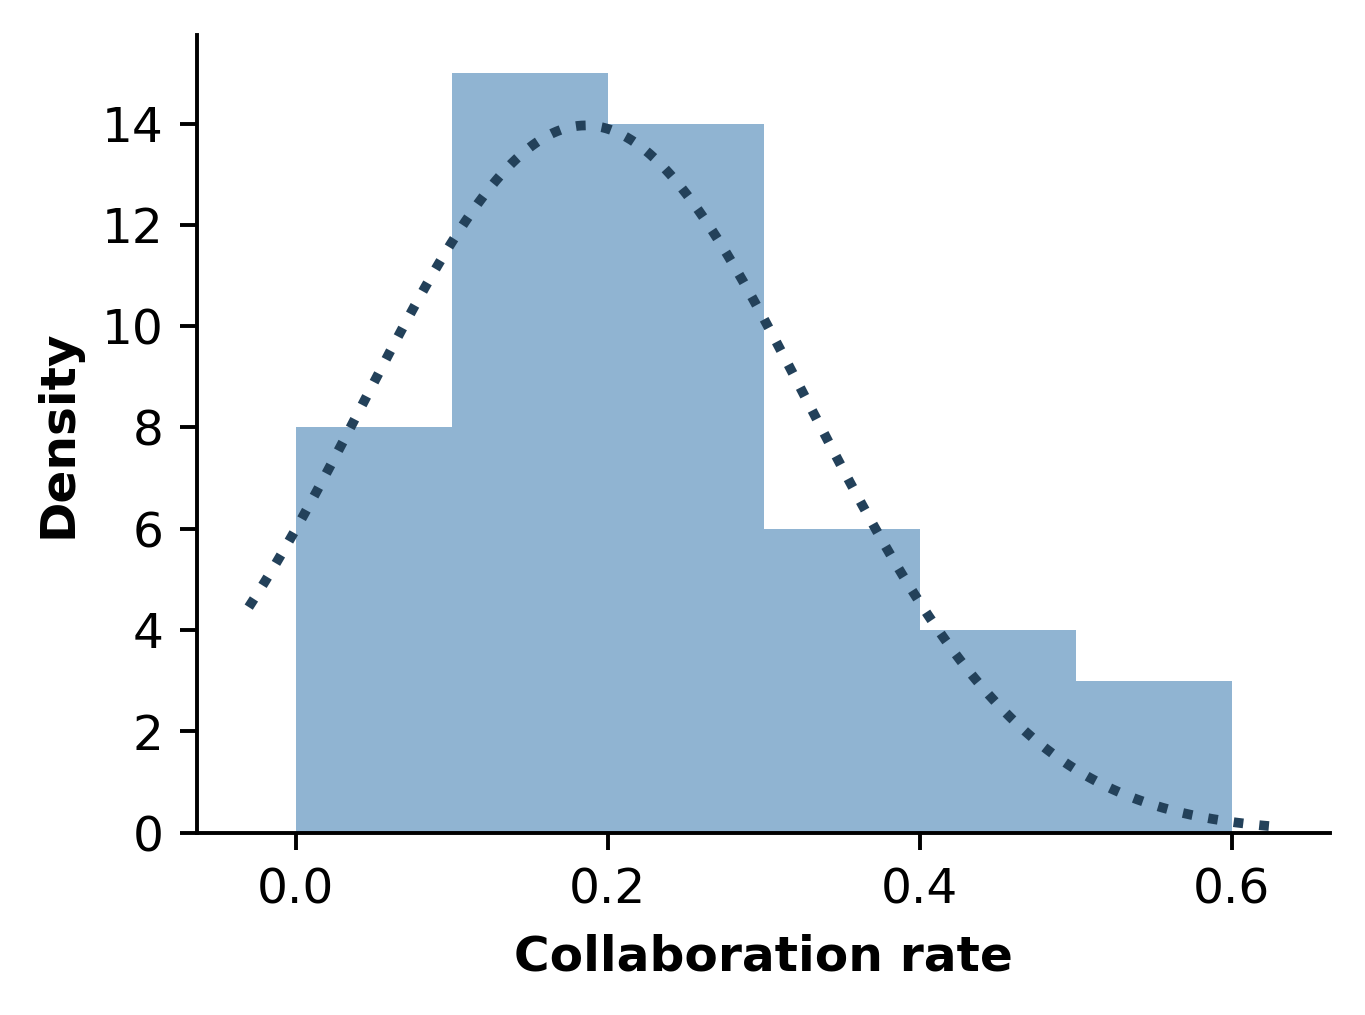

In [290]:
_collab_df = all_metrics_outside_random_5euro_df[all_metrics_outside_random_5euro_df['instance'].between(0,50)]
figure_plot.hist_plot(_collab_df,
                      col1='collaboration_rate',
                      n_bins=7,
                      figure_size=(4,3),
                      ylabel = 'Density',
                      xlabel = 'Collaboration rate',
                      hide_labels=False,
                      hide_legends=True
                      )

### VKT

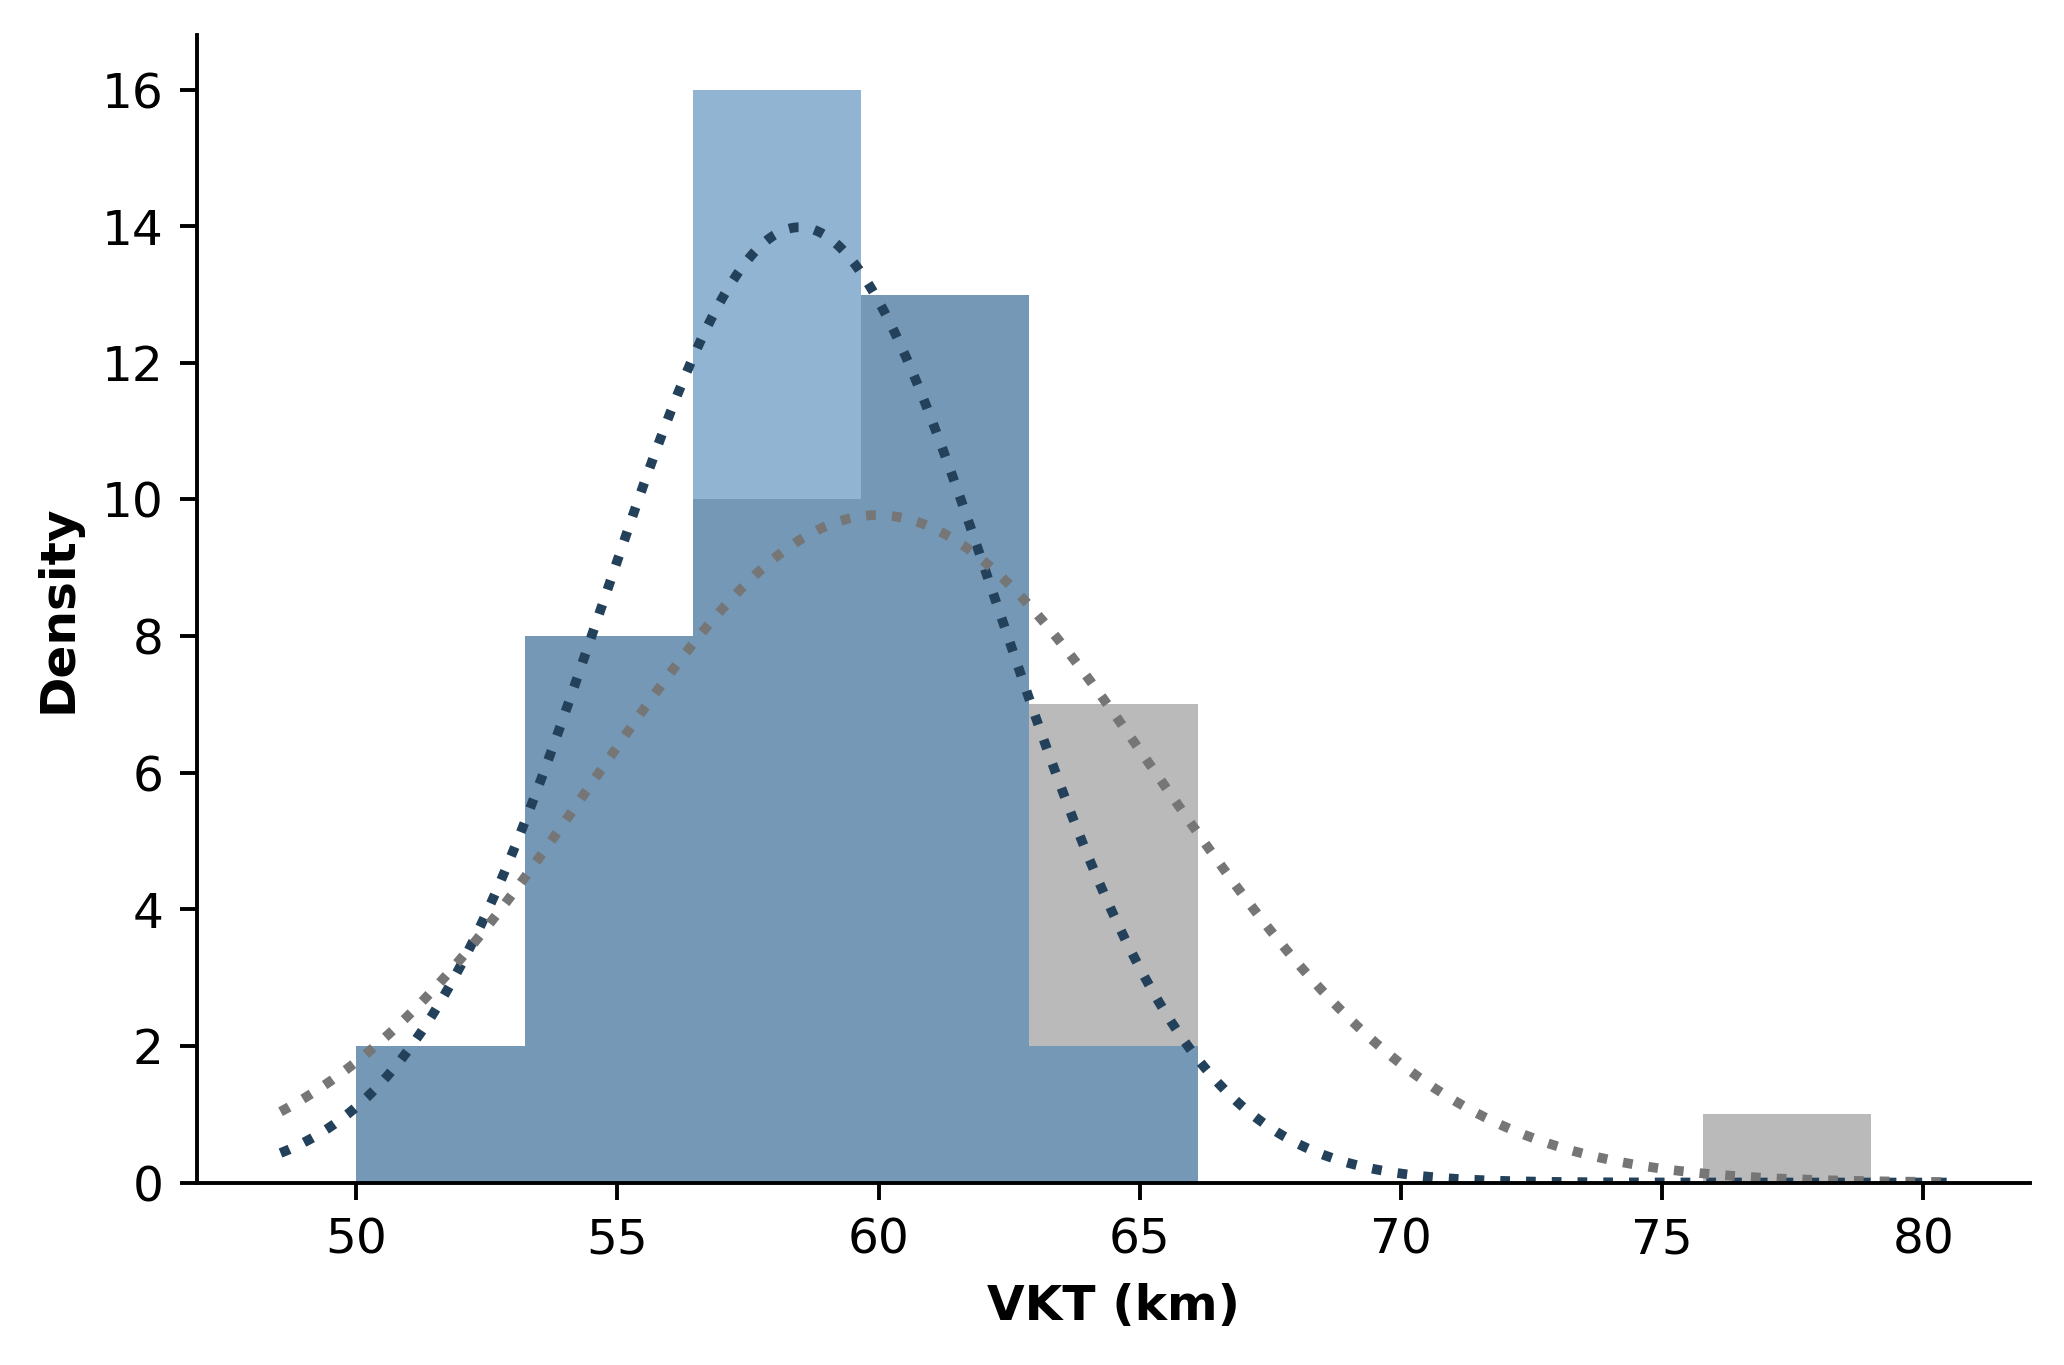

the mean reduction in VKT for 5 euro penalty is: 1.4878048780487845


In [248]:
_vkt_df = all_metrics_outside_random_5euro_df[all_metrics_outside_random_5euro_df['instance'].between(0, 40)]
figure_plot.hist_plot(_vkt_df,
                      col1='VKT_km',
                      col2='iter0_VKT_km',
                      n_bins=10,
                      figure_size=(6,4),
                      ylabel = 'Density',
                      xlabel = 'VKT (km)',
                      hide_labels=False,
                      hide_legends=True
                      )
print("the mean reduction in VKT for 5 euro penalty is:",
       (_vkt_df['iter0_VKT_km'].mean() - _vkt_df['VKT_km'].mean()))

### VTT

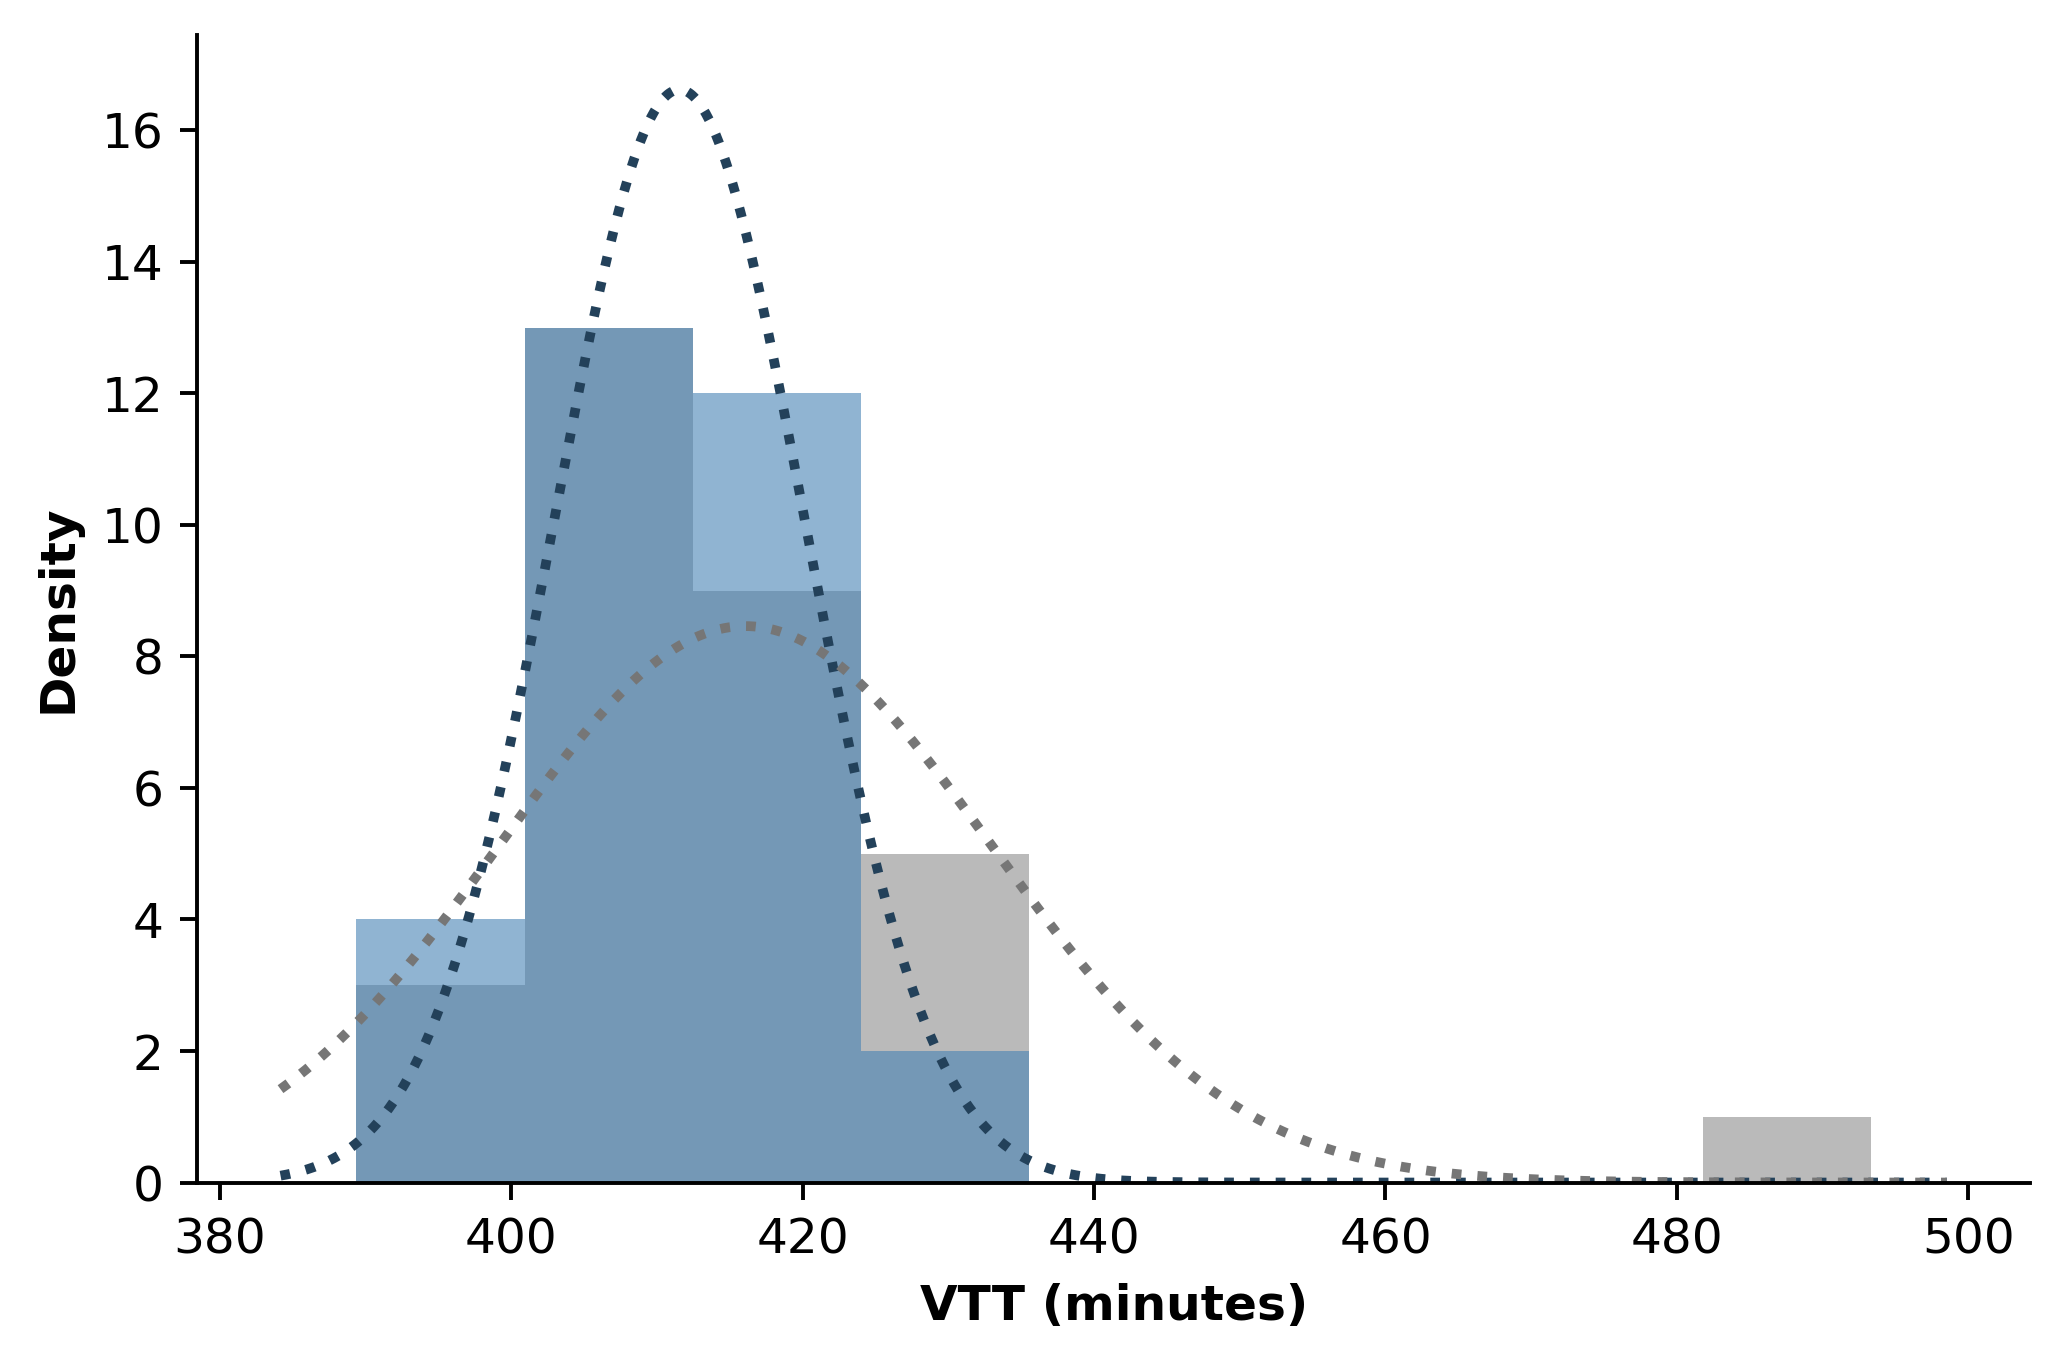

the mean reduction of VTT is: 4.518817204301172


In [292]:
vtt_minutes_df = all_metrics_outside_random_5euro_df.copy()
vtt_minutes_df[['VTT_seconds', 'iter0_VTT_seconds']] = (
    vtt_minutes_df[['VTT_seconds', 'iter0_VTT_seconds']] / 60
)
_vtt_minutes_df = vtt_minutes_df[vtt_minutes_df['instance'].between(0,30)]
figure_plot.hist_plot(_vtt_minutes_df,
                      col1='VTT_seconds',
                      col2='iter0_VTT_seconds',
                      n_bins=10,
                      figure_size=(6,4),
                      ylabel='Density',
                      xlabel='VTT (minutes)',
                      hide_labels=False,
                      hide_legends=True
                      )
print("the mean reduction of VTT is: {}".format(
    -(_vtt_minutes_df['VTT_seconds'].mean() 
        - _vtt_minutes_df['iter0_VTT_seconds'].mean())) 
        )

### Ton-km travelled

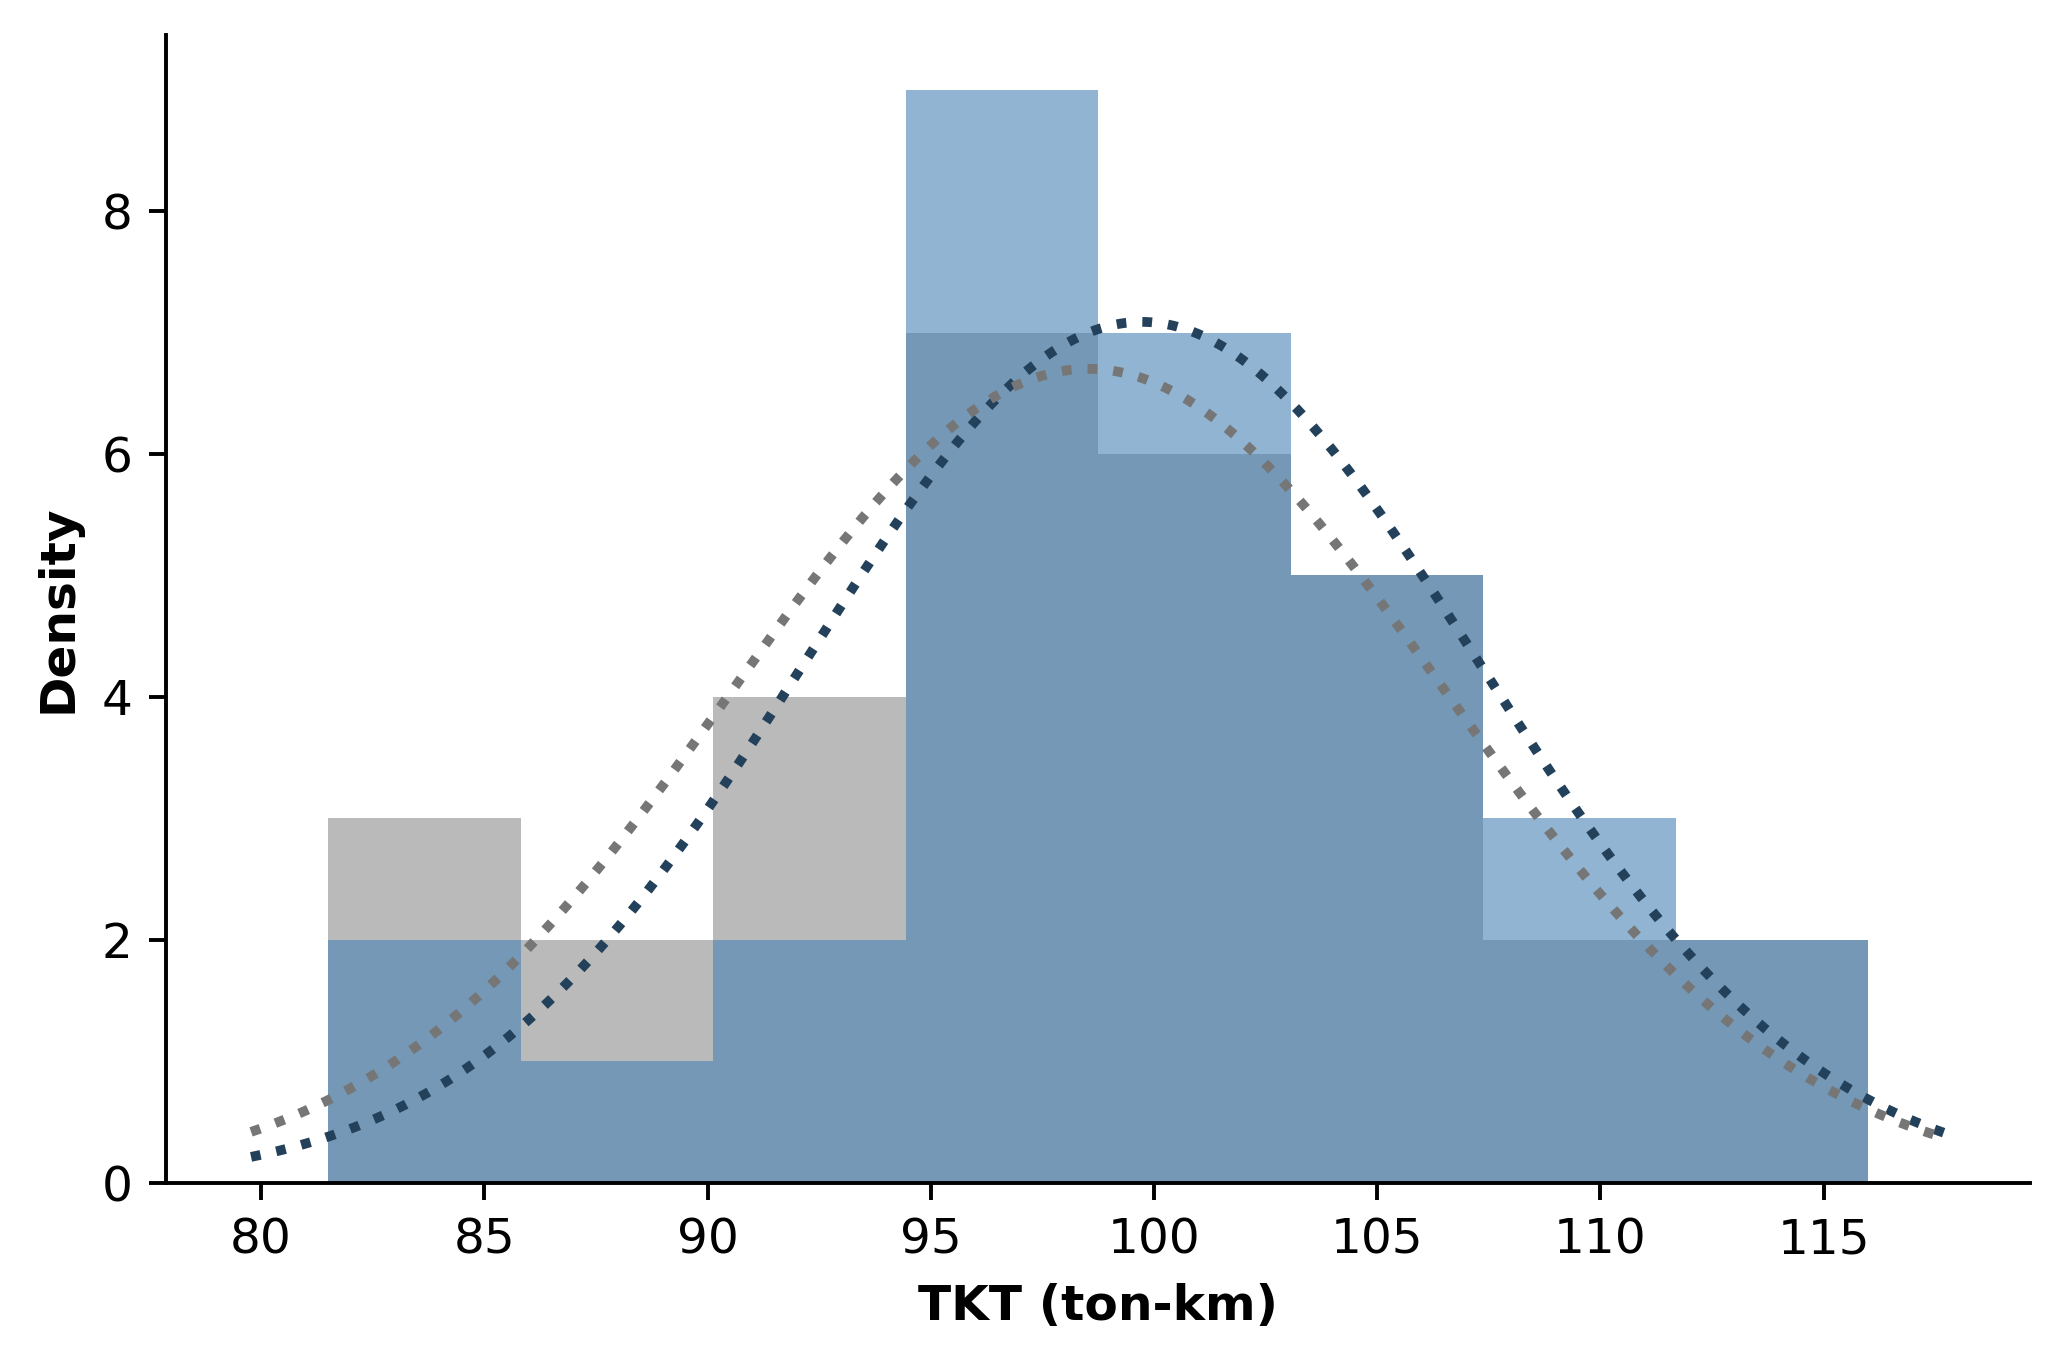

the mean increase of TKT is: 1.1935483870967687


In [294]:
tkt_ton_df = all_metrics_outside_random_5euro_df.copy()
tkt_ton_df[['TKT_tonkm', 'iter0_TKT_tonkm']] = (
    tkt_ton_df[['TKT_tonkm', 'iter0_TKT_tonkm']] / 1000
)
_tkt_ton_df = tkt_ton_df[tkt_ton_df['instance'].between(0,30)]
figure_plot.hist_plot(_tkt_ton_df,
                        col1='TKT_tonkm',
                        col2='iter0_TKT_tonkm',
                        n_bins=9,
                        figure_size=(6,4),
                        ylabel='Density',
                        xlabel='TKT (ton-km)',
                        hide_labels=False,
                        hide_legends=True
                        )
print("the mean increase of TKT is: {}".format(
    (_tkt_ton_df['TKT_tonkm'].mean()
        - _tkt_ton_df['iter0_TKT_tonkm'].mean())) 
        )


### Cost savings

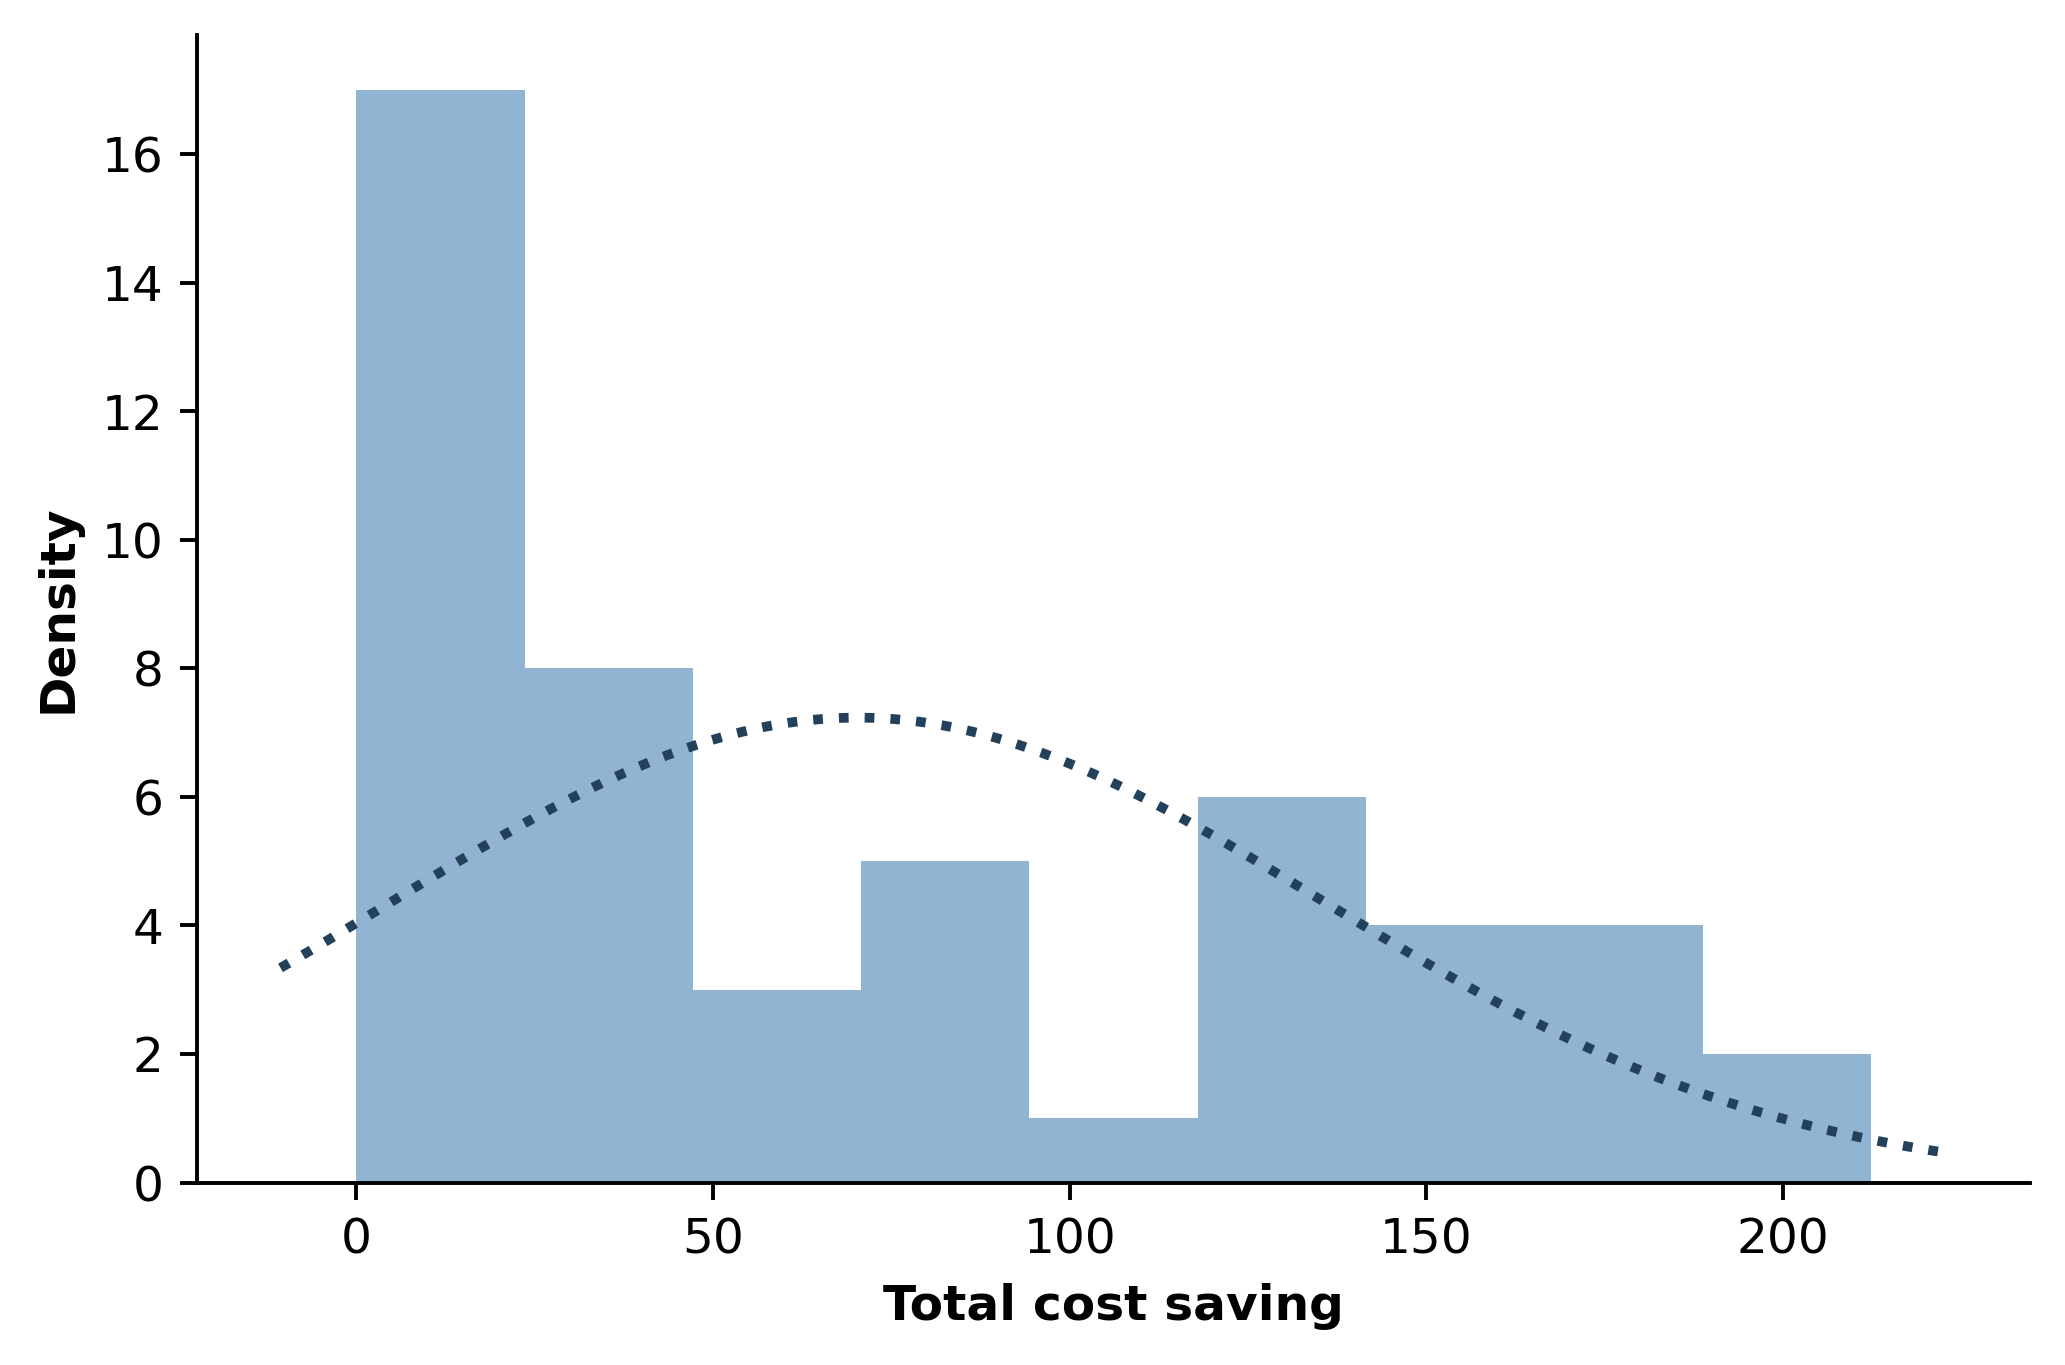

In [254]:
_cost_saving_df = all_metrics_outside_random_5euro_df[all_metrics_outside_random_5euro_df['instance'].between(0,50)]
figure_plot.hist_plot(_cost_saving_df,
                      col1='total_cost_savings',
                      n_bins=10,
                      figure_size=(6,4),
                      ylabel='Density',
                      xlabel='Total cost saving',
                      hide_labels=False,
                      hide_legends=True
                      )

### Carrier score

C:\Users\Xander\AppData\Local\Temp\ipykernel_37640\3957544022.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _carrier_score_df.query("iter0_carrier_score >= 450", inplace=True)


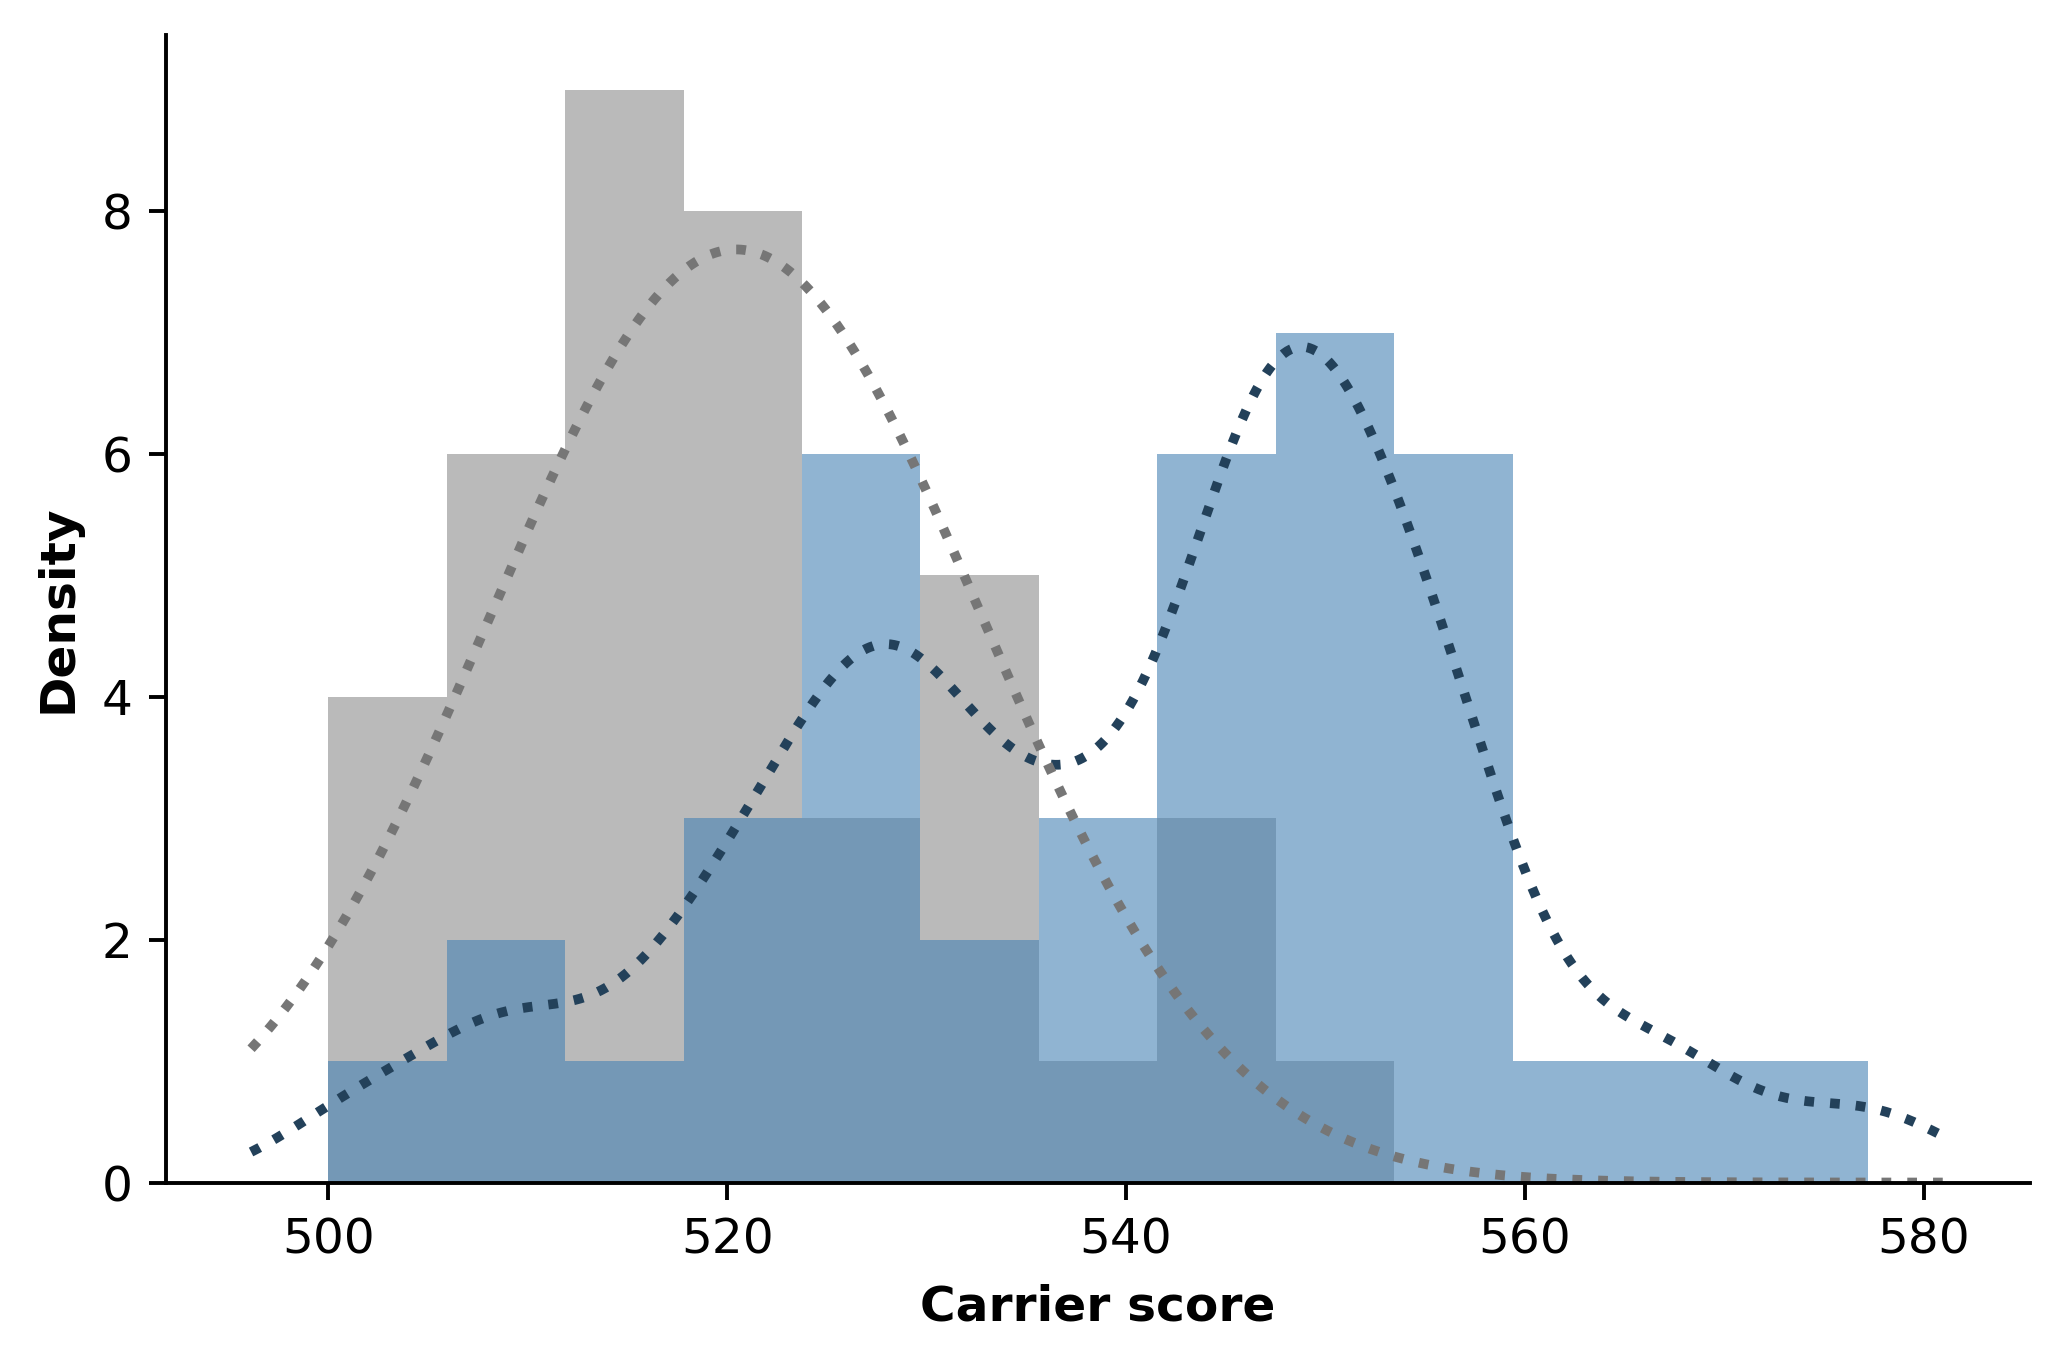

the mean increase of carrier score is: 19.43932772749963


In [314]:
_carrier_score_df = all_metrics_outside_random_5euro_df[all_metrics_outside_random_5euro_df['instance'].between(0,40)]
_carrier_score_df.query("iter0_carrier_score >= 450", inplace=True)
figure_plot.hist_plot(_carrier_score_df,
                        col1='final_carrier_score',
                        col2='iter0_carrier_score',
                        n_bins=14,
                        figure_size=(6,4),
                        ylabel='Density',
                        xlabel='Carrier score',
                        fitting_method=('kde', 'normal'),
                        hide_labels=False,
                        hide_legends=True,
                        kde_bw=0.25
                        )
print("the mean increase of carrier score is: {}".format(
    (_carrier_score_df['final_carrier_score'].mean() - _carrier_score_df['iter0_carrier_score'].mean())) 
    )

### Reciever score

C:\Users\Xander\AppData\Local\Temp\ipykernel_37640\1414695619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _receiver_score_df.query("total_receiver_scores >= -1000", inplace=True)
d:\anaconda3\envs\TransAndGeo\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


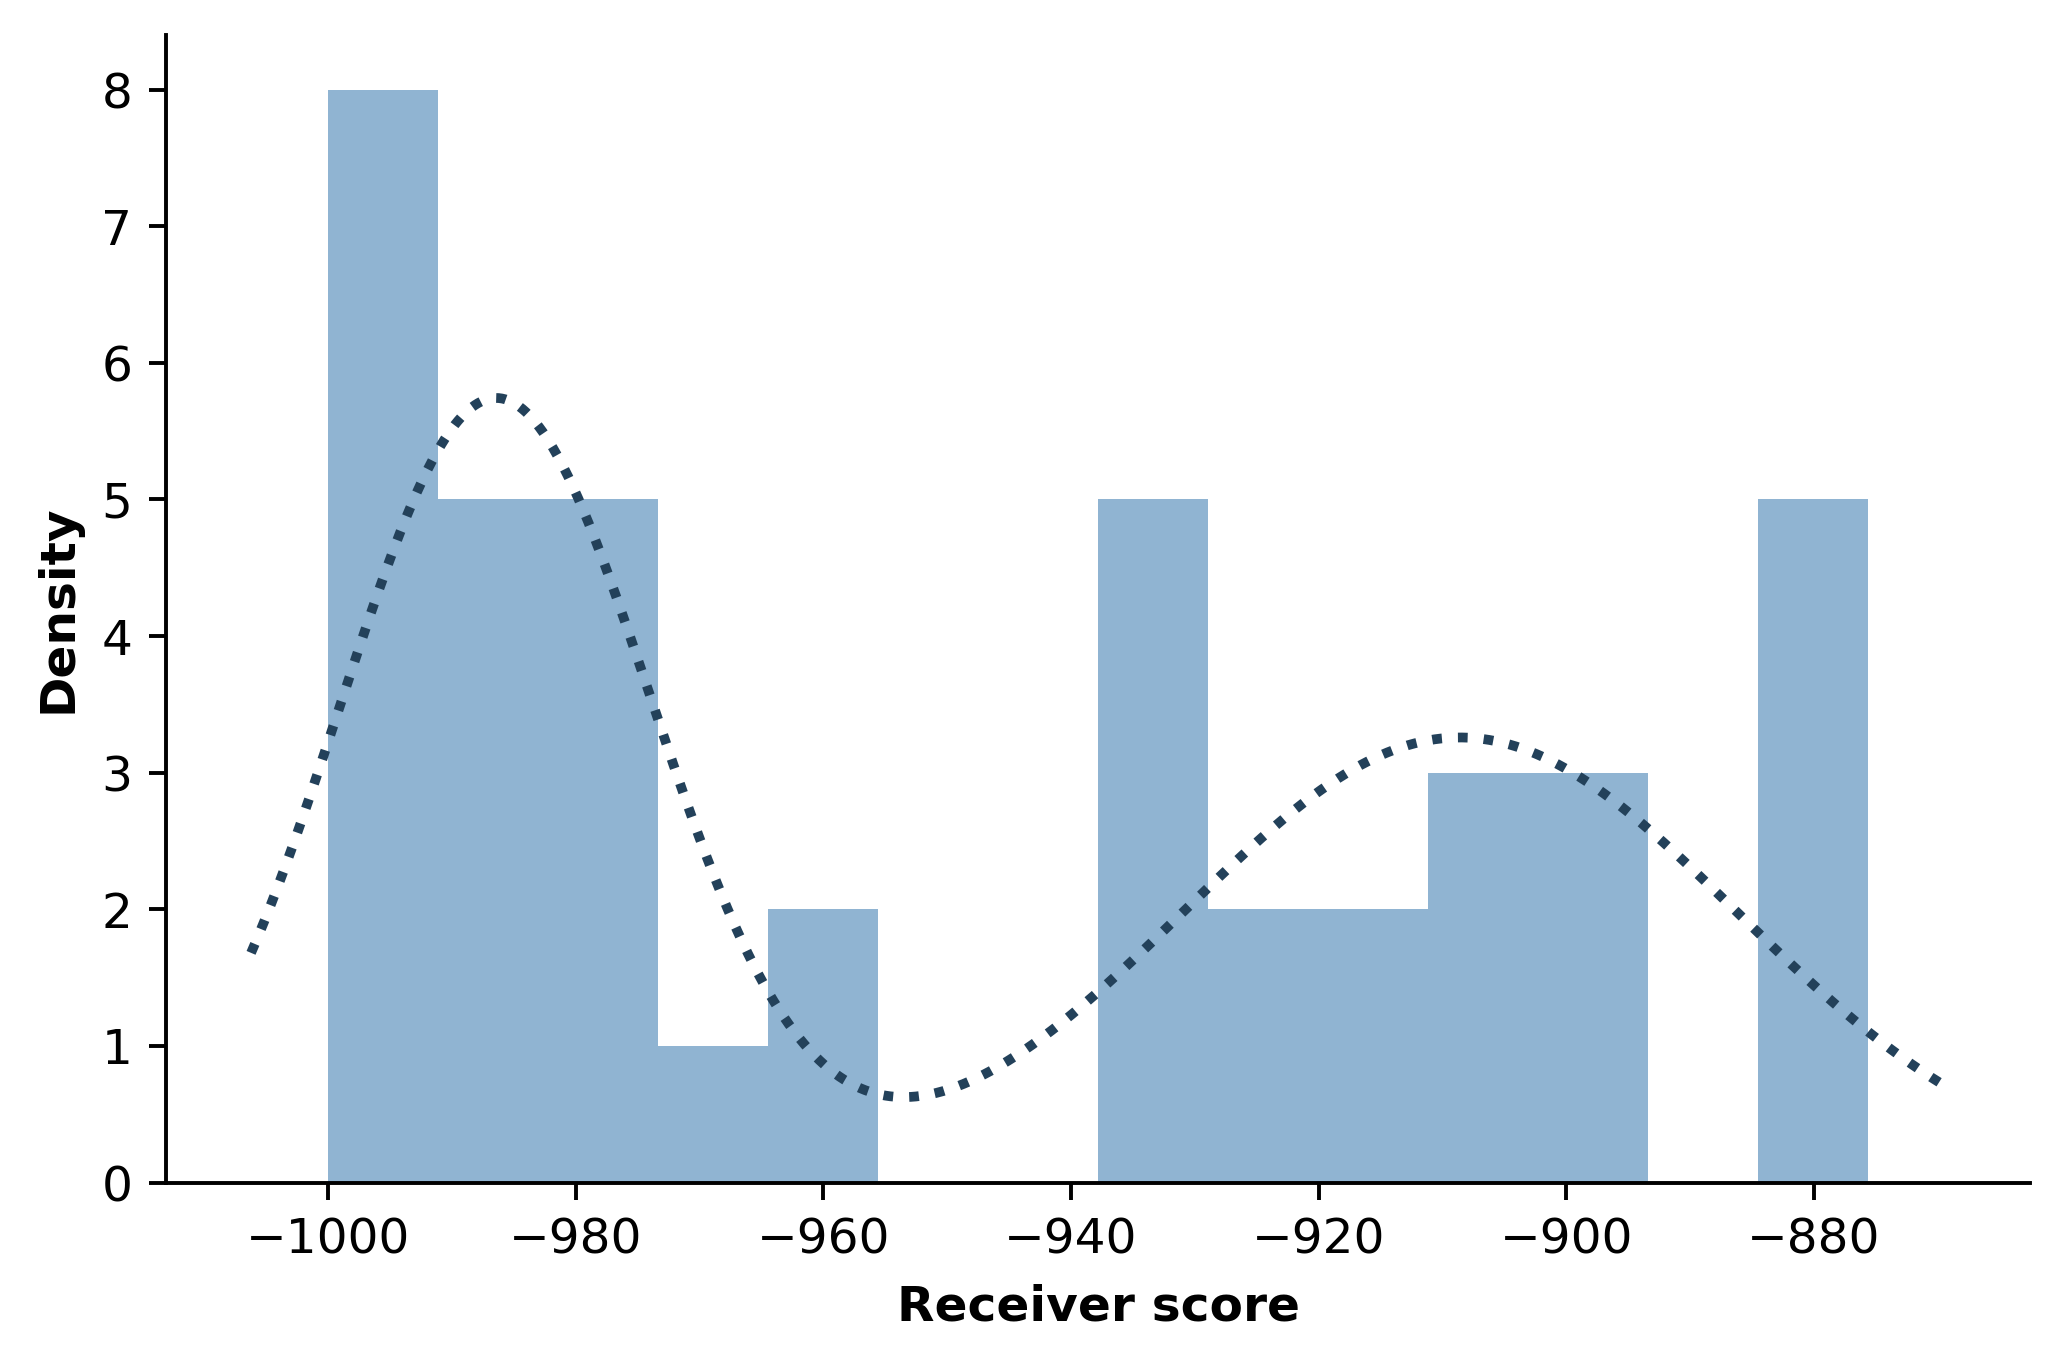

In [318]:
_receiver_score_df = all_metrics_outside_random_5euro_df[all_metrics_outside_random_5euro_df['instance'].between(0,40)]
_receiver_score_df.query("total_receiver_scores >= -1000", inplace=True)
figure_plot.hist_plot(_receiver_score_df,
                        col1='total_receiver_scores',
                        # col2='iter0_total_receiver_scores',
                        n_bins=15,
                        figure_size=(6,4),
                        ylabel='Density',
                        xlabel='Receiver score',
                        hide_labels=False,
                        hide_legends=True,
                        fitting_method='gmm',
                        kde_bw=0.3,
                        is_fitting=True 
                        )

### TWs

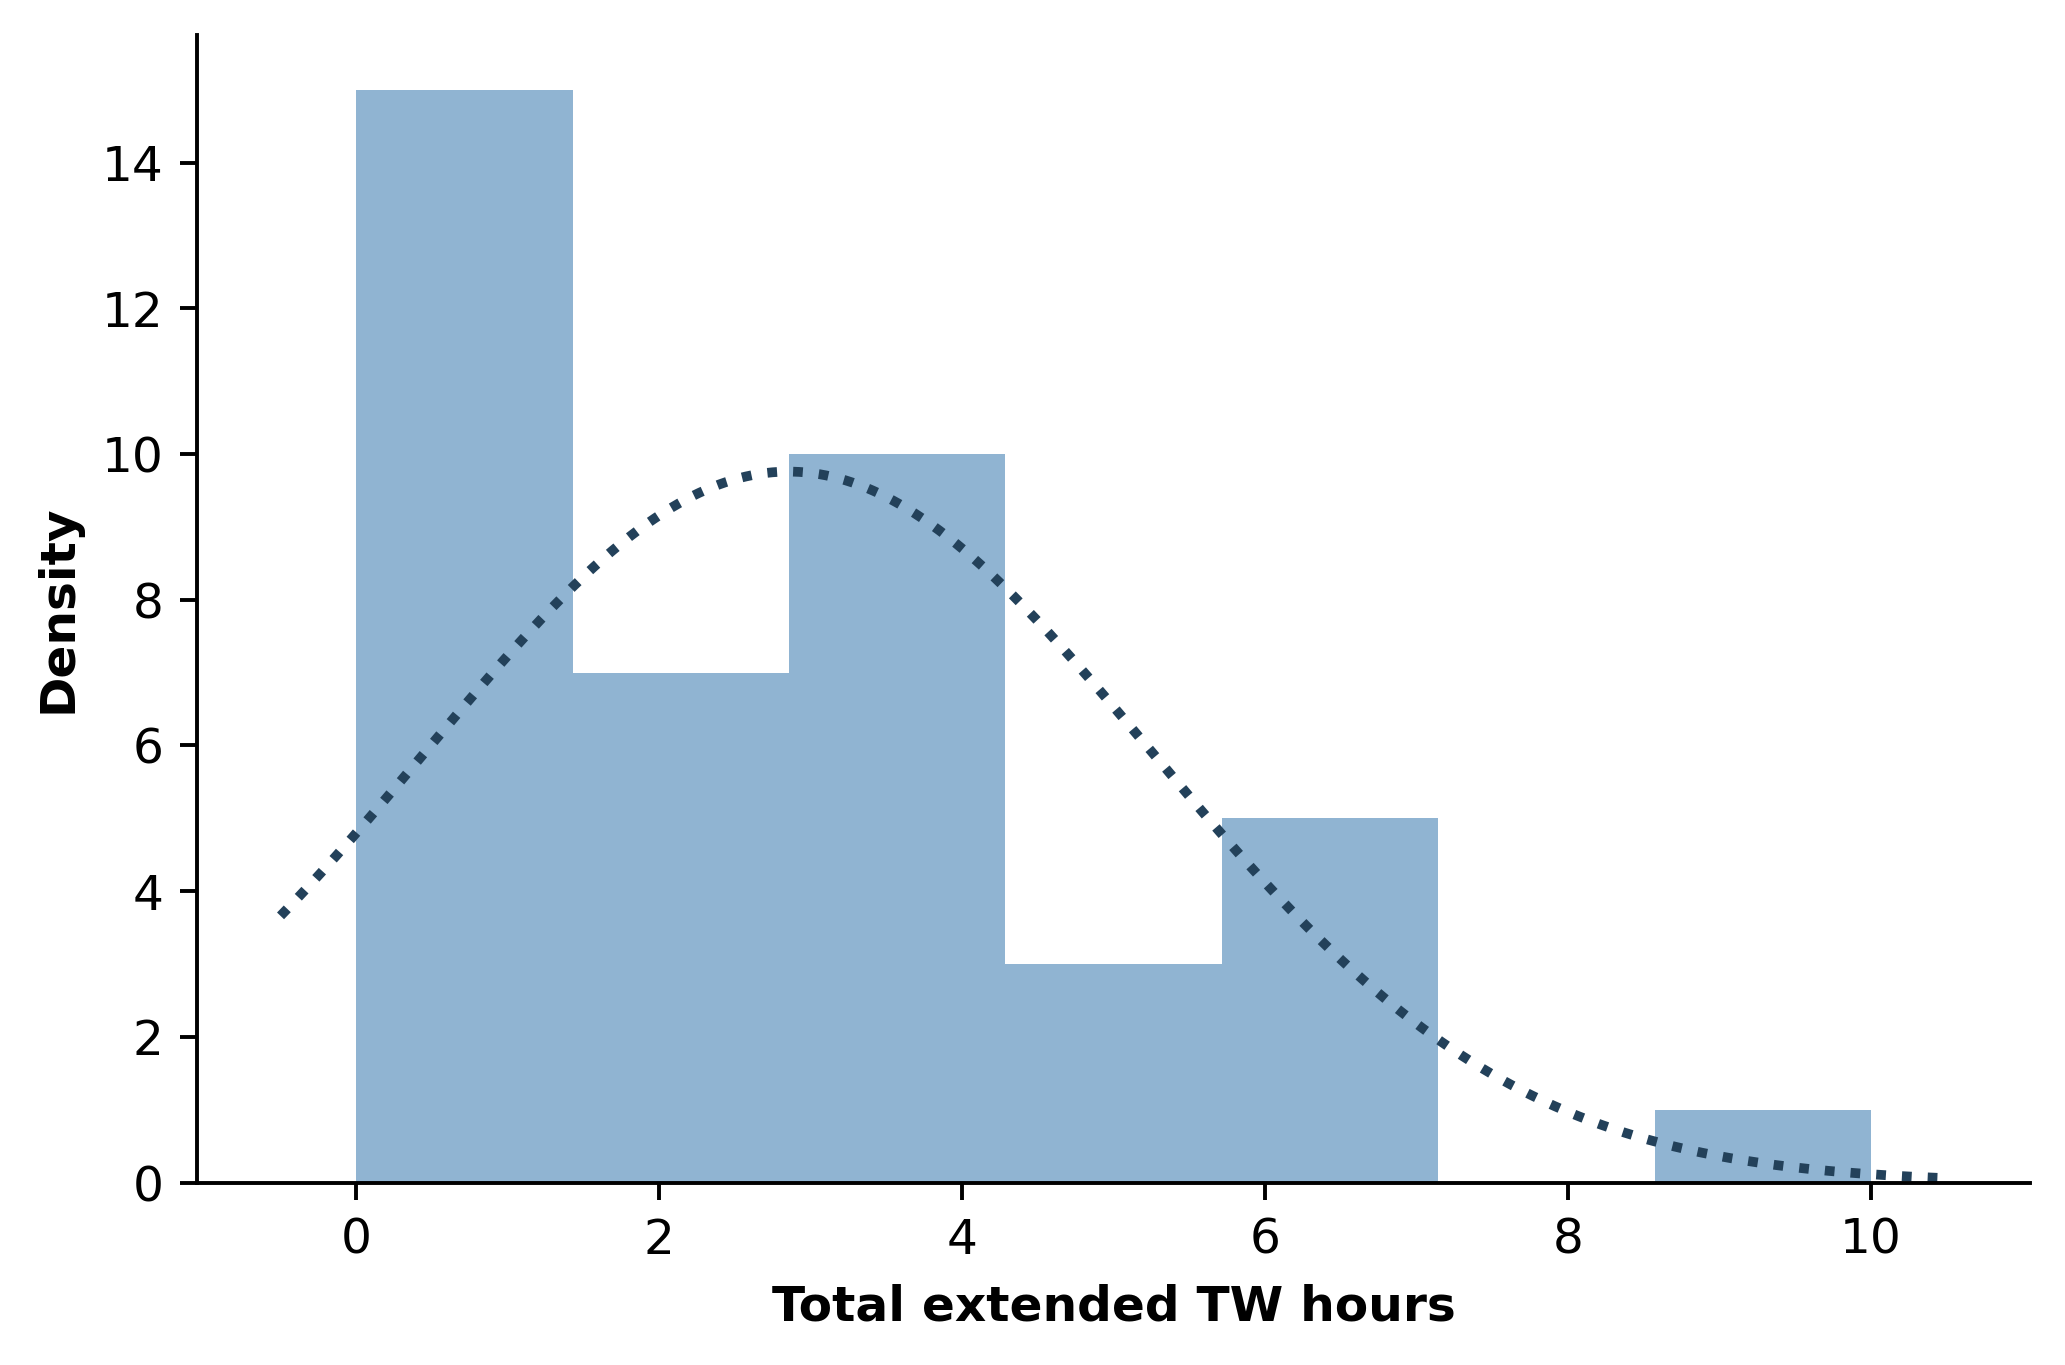

the mean extended TW hours is: 2.8536585365853657


In [320]:
_tws_df = all_metrics_outside_random_5euro_df[all_metrics_outside_random_5euro_df['instance'].between(0,40)]
figure_plot.hist_plot(_tws_df,
                      col1='total_extended_tw_hours',
                      n_bins=8,
                      figure_size=(6,4),
                      ylabel='Density',
                      xlabel='Total extended TW hours',
                      hide_labels=False,
                      hide_legends=True
                      )
print("the mean extended TW hours is: {}".format(
    (_tws_df['total_extended_tw_hours'].mean())) 
    )

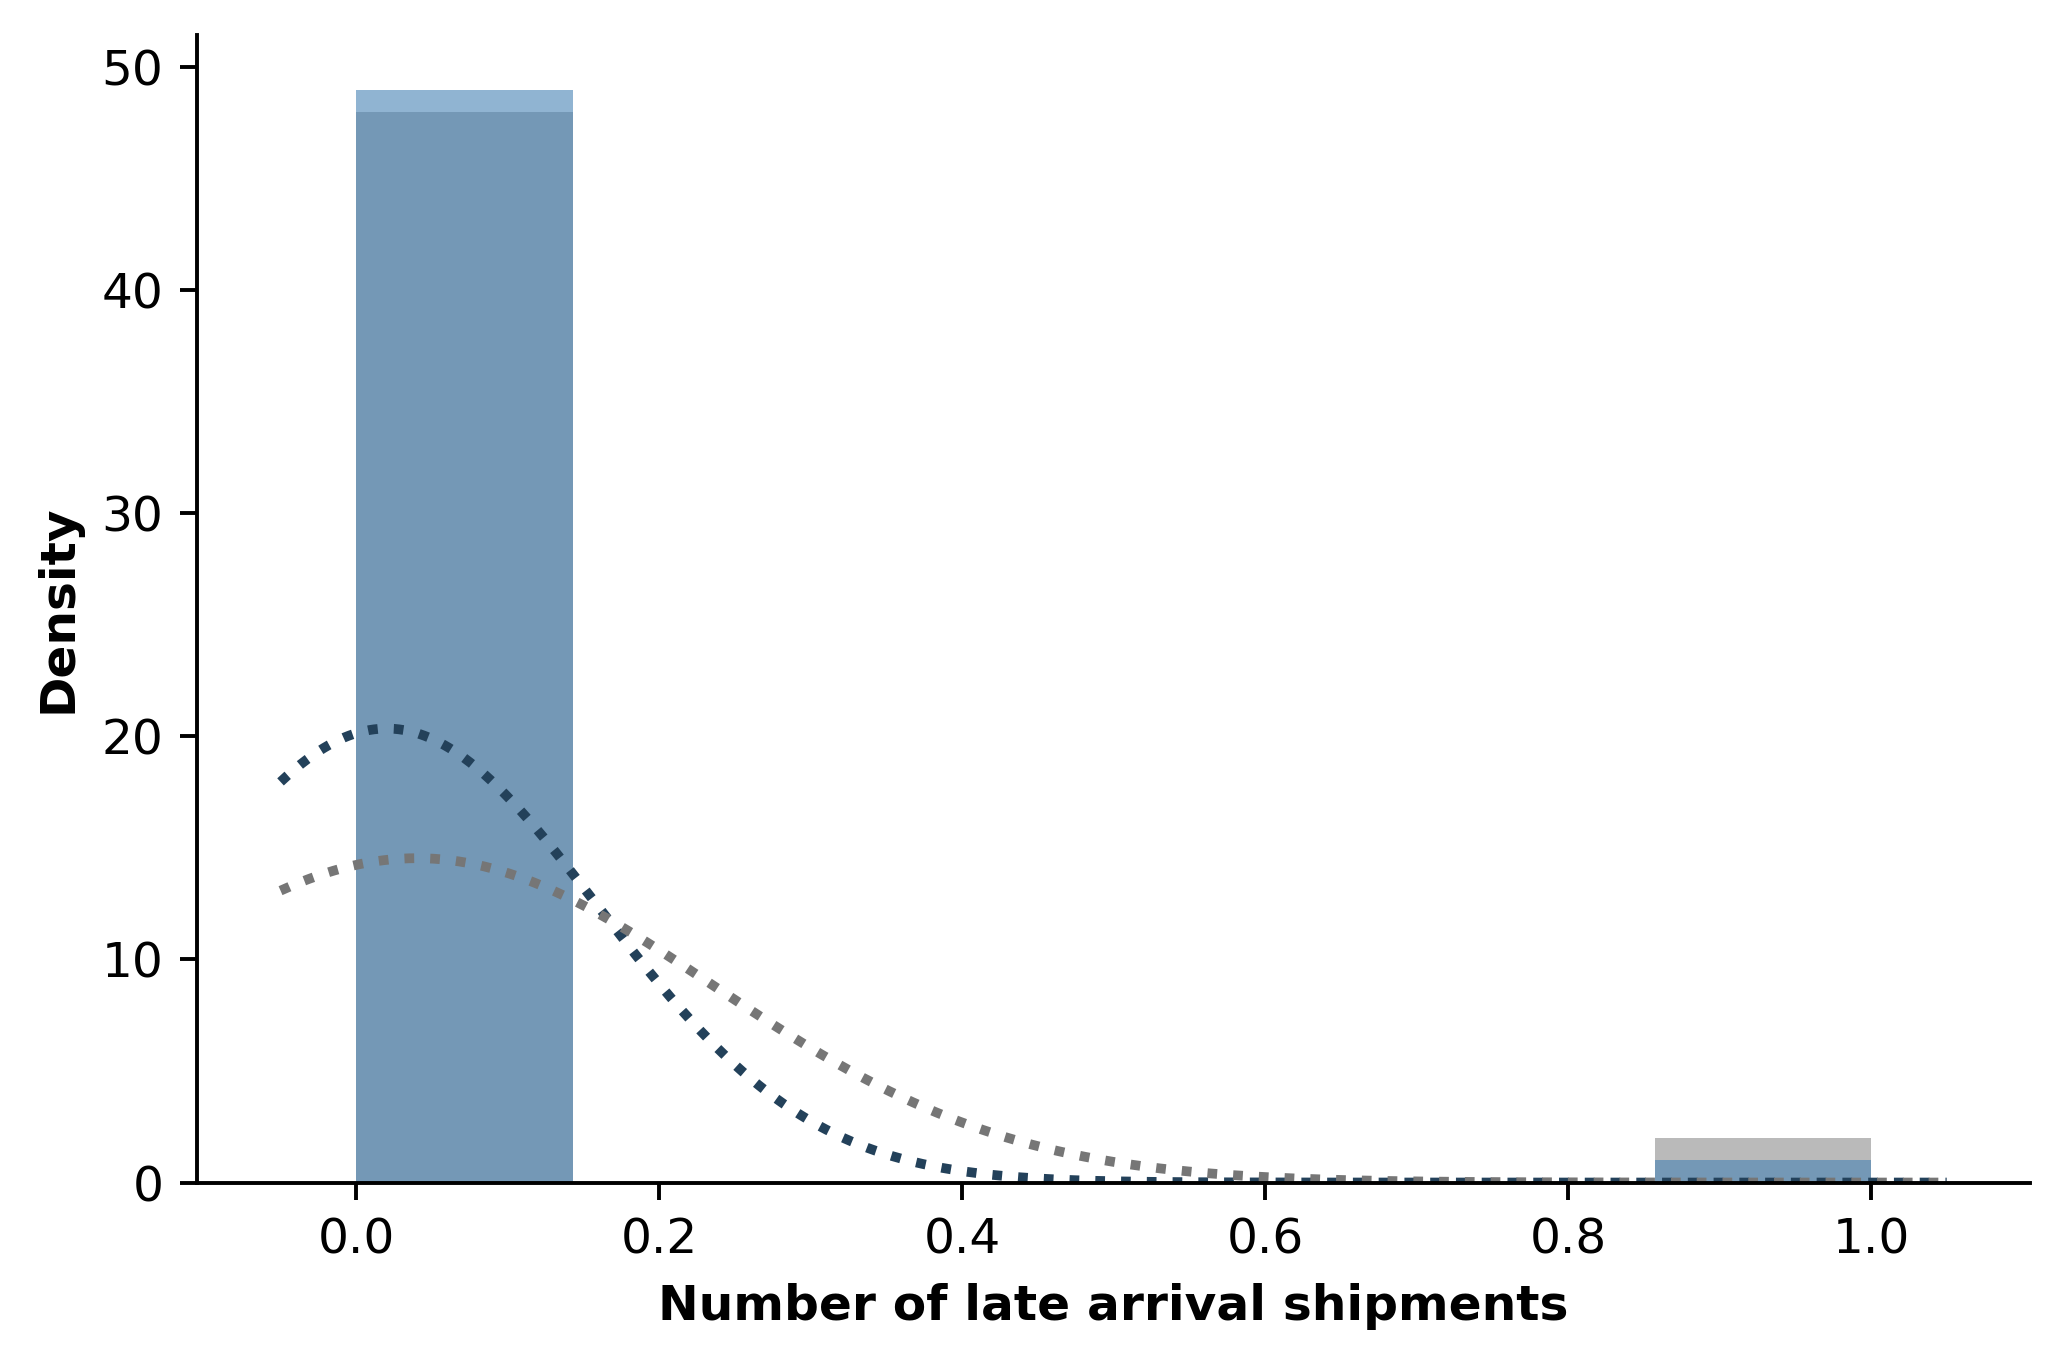

In [333]:
_tw_shipment_df = all_shipment_metrics_outside_random_5euro_df[all_shipment_metrics_outside_random_5euro_df['instance_id'].between(0,50)]
_tw_shipment_df

figure_plot.hist_plot(_tw_shipment_df,
                        col1='final_late_arrival_count',
                        col2='iter0_late_arrival_count',
                        n_bins=8,
                        figure_size=(6,4),
                        ylabel='Density',
                        xlabel='Number of late arrival shipments',
                        hide_labels=False,
                        hide_legends=True
                        )

In [338]:
__shipment_df = pd.read_csv(r'F:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean\left-FULLY_RANDOM-af0.80-p0.0222-i21\shipments.csv.gz')
__shipment_df

,carrier_id,shipment_id,pickup_link_id,delivery_link_id,size,start_pickup,end_pickup,start_delivery,end_delivery,pickup_service_time,...,iter0_delivery_link,iter0_pickup_time,iter0_delivery_time,iter0_travel_time_seconds,iter0_travel_distance_km,iter0_capacity_demand,depot_location,receiver_distribution,penalty,instance
0,carrier1,Orderreceiver_001,"i(1,0)","i(6,6)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"i(6,6)",18004.0,26542.0,8538.0,24.0,500.0,left,FULLY_RANDOM,0.0222,21
1,carrier1,Orderreceiver_012,"i(1,0)","i(7,4)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"i(7,4)",18002.0,19705.0,1703.0,14.0,500.0,left,FULLY_RANDOM,0.0222,21
2,carrier1,Orderreceiver_023,"i(1,0)","j(2,7)R",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(2,7)R",18001.0,26408.0,8407.0,27.0,500.0,left,FULLY_RANDOM,0.0222,21
3,carrier1,Orderreceiver_034,"i(1,0)","j(5,4)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(5,4)",18003.0,23202.0,5199.0,16.0,500.0,left,FULLY_RANDOM,0.0222,21
4,carrier1,Orderreceiver_045,"i(1,0)","j(7,3)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(7,3)",18000.0,19211.0,1211.0,15.0,500.0,left,FULLY_RANDOM,0.0222,21
5,carrier1,Orderreceiver_056,"i(1,0)","j(3,6)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(3,6)",18001.0,24939.0,6938.0,23.0,500.0,left,FULLY_RANDOM,0.0222,21
6,carrier1,Orderreceiver_067,"i(1,0)","i(4,7)R",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"i(4,7)R",18003.0,24939.0,6936.0,22.0,500.0,left,FULLY_RANDOM,0.0222,21
7,carrier1,Orderreceiver_078,"i(1,0)","j(7,6)",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(7,6)",18000.0,23068.0,5068.0,19.0,500.0,left,FULLY_RANDOM,0.0222,21
8,carrier1,Orderreceiver_089,"i(1,0)","j(2,6)R",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(2,6)R",18004.0,27743.0,9739.0,26.0,500.0,left,FULLY_RANDOM,0.0222,21
9,carrier1,Orderreceiver_0910,"i(1,0)","j(6,6)R",500,00:00:00,596523:14:07,06:00:00,08:00:00,00:00:00,...,"j(6,6)R",18002.0,27877.0,9875.0,28.0,500.0,left,FULLY_RANDOM,0.0222,21


In [339]:
__shipment_df['final_delivery_time'] / 3600

0    5.410833
1    6.853056
2    7.298333
3    6.445000
4    5.436389
5    6.853056
6    7.780833
7    7.261111
8    7.669167
9    6.370556
Name: final_delivery_time, dtype: float64

## Penalty sensitivity

In [112]:
agg_metrics_center_random_df = agg_random_df_across_instances(all_metrics_center_random_df)
agg_metrics_outside_random_df = agg_random_df_across_instances(all_metrics_outside_random_df)

### collaboration rate

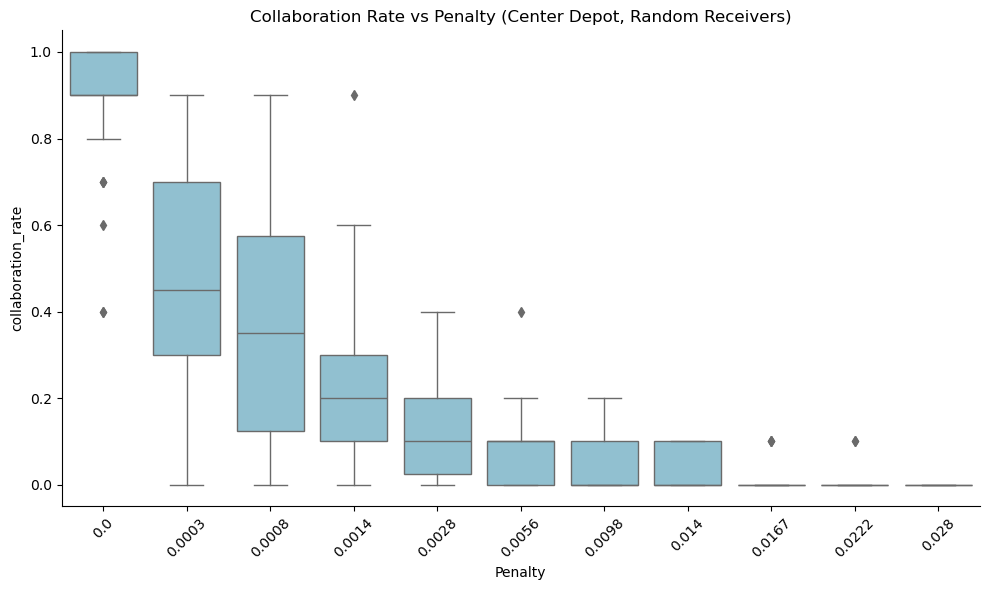

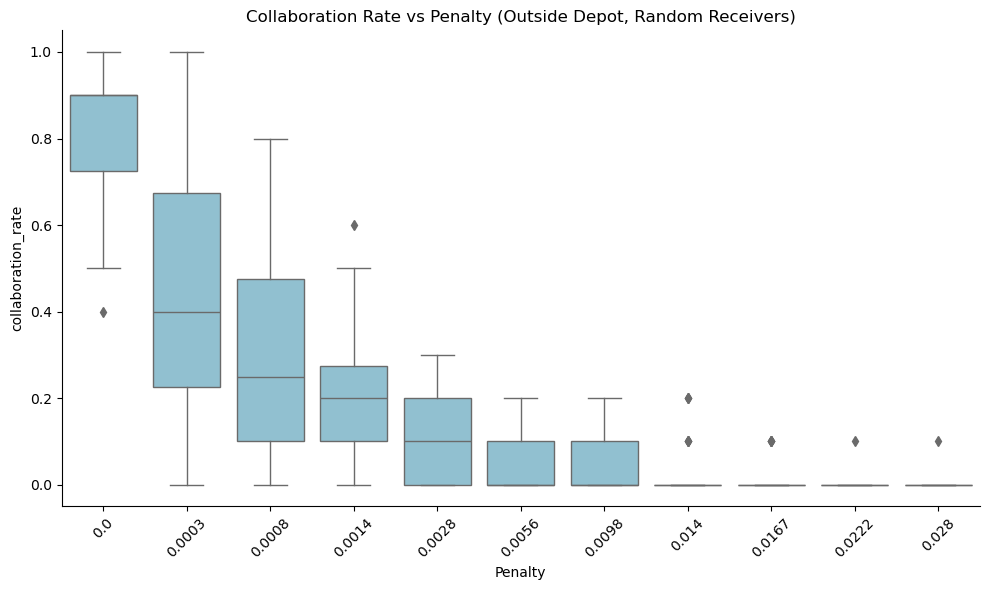

In [149]:
boxplot_metric(all_metrics_center_random_df,
               metric='collaboration_rate',
               title='Collaboration Rate vs Penalty (Center Depot, Random Receivers)',  
               compare_iter0=False)
boxplot_metric(all_metrics_outside_random_df,
               metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Outside Depot, Random Receivers)',
                compare_iter0=False)


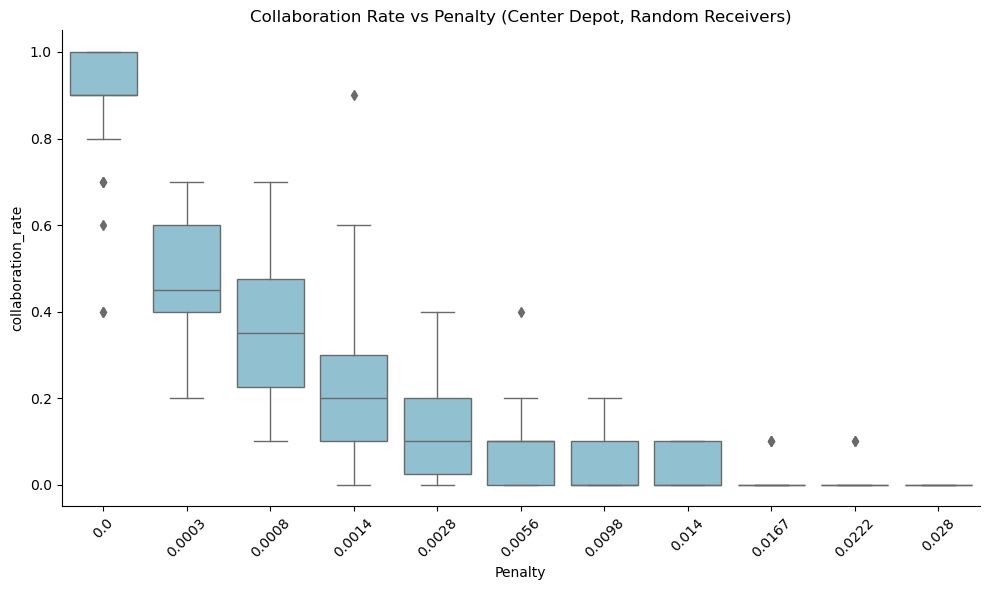

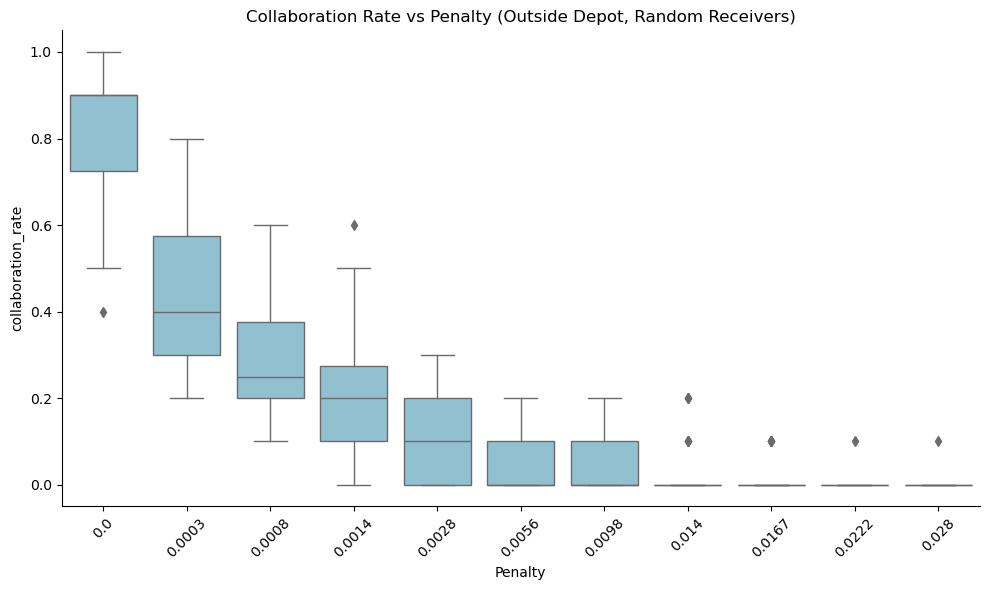

In [154]:
boxplot_metric(shrink_group_variance(all_metrics_center_random_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     alpha=0.6,
                                     center='median',
                                     groups=[0.0003, 0.0008],
                                     value_step=0.1),
               metric='collaboration_rate',
               title='Collaboration Rate vs Penalty (Center Depot, Random Receivers)',  
               compare_iter0=False)
boxplot_metric(shrink_group_variance(all_metrics_outside_random_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     alpha=0.6,
                                     center='median',
                                     groups=[0.0003, 0.0008],
                                     value_step=0.1),
               metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Outside Depot, Random Receivers)',
                compare_iter0=False)

### VKT

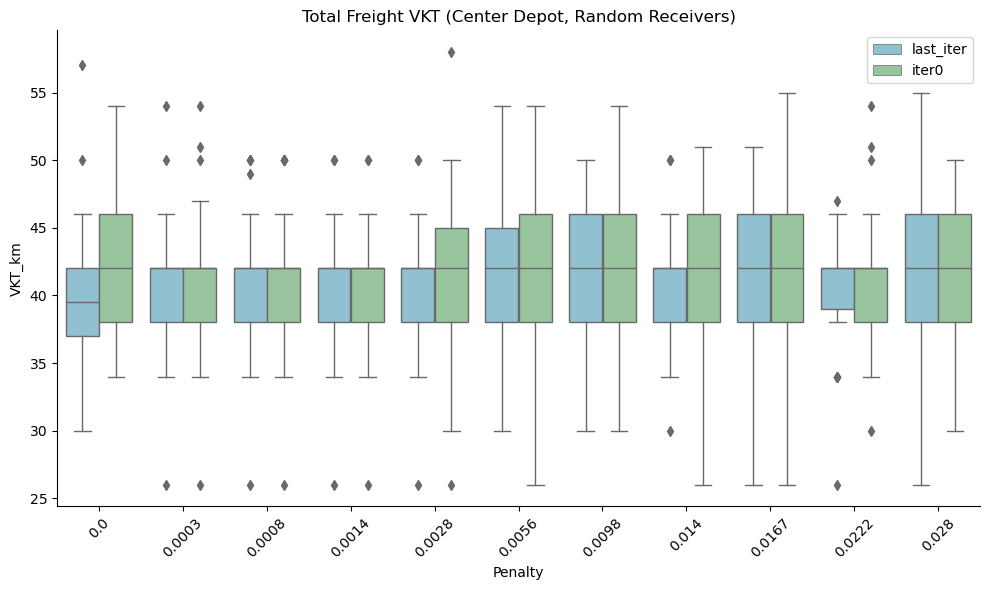

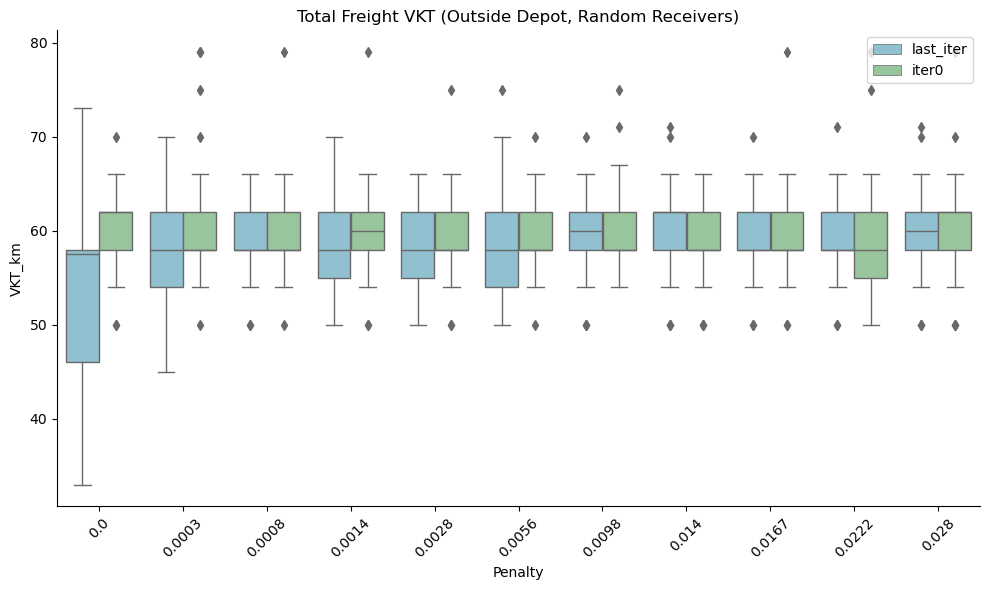

In [142]:
boxplot_metric(all_metrics_center_random_df, 
               metric='VKT_km', 
               title='Total Freight VKT (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='VKT_km', 
                title='Total Freight VKT (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### VTT (travel time)

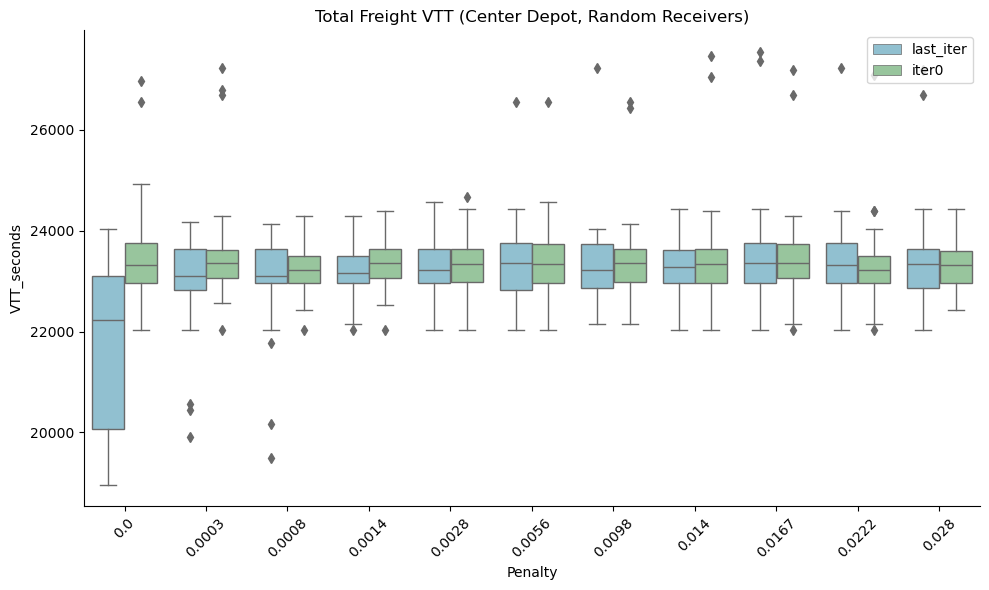

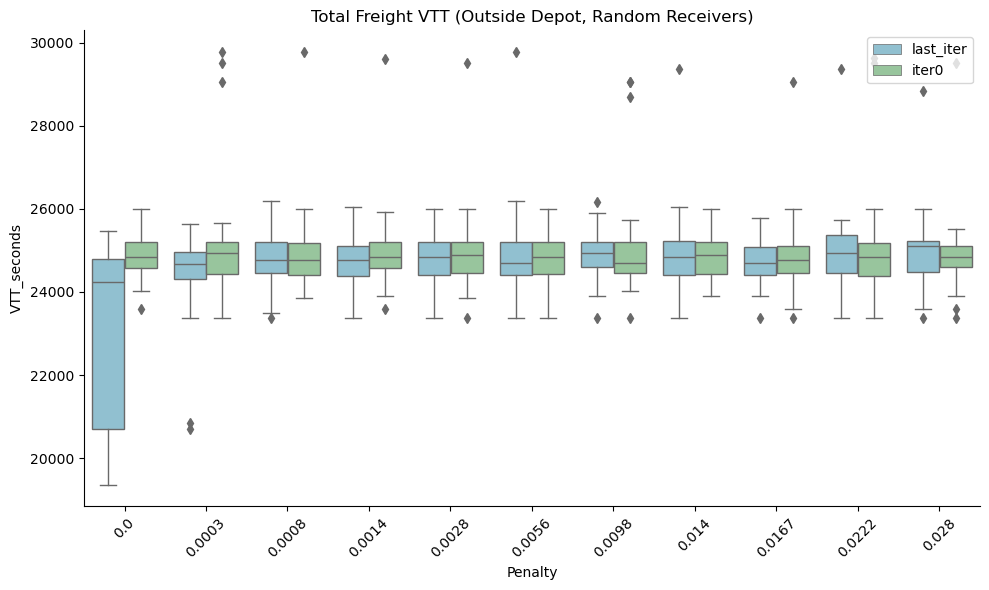

In [158]:
boxplot_metric(all_metrics_center_random_df, 
               metric='VTT_seconds', 
               title='Total Freight VTT (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='VTT_seconds', 
                title='Total Freight VTT (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### Ton-km travelled (tkt)

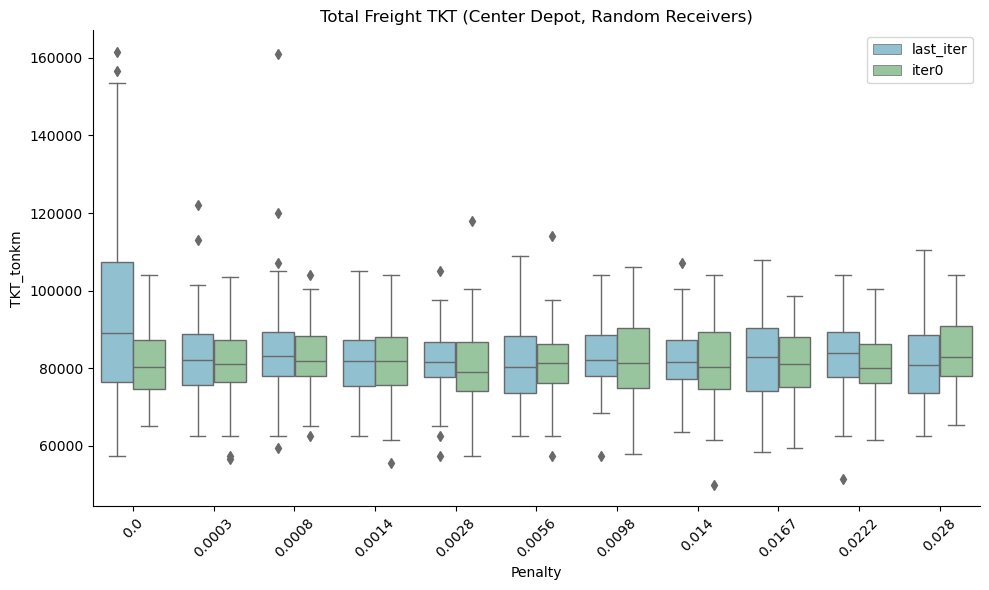

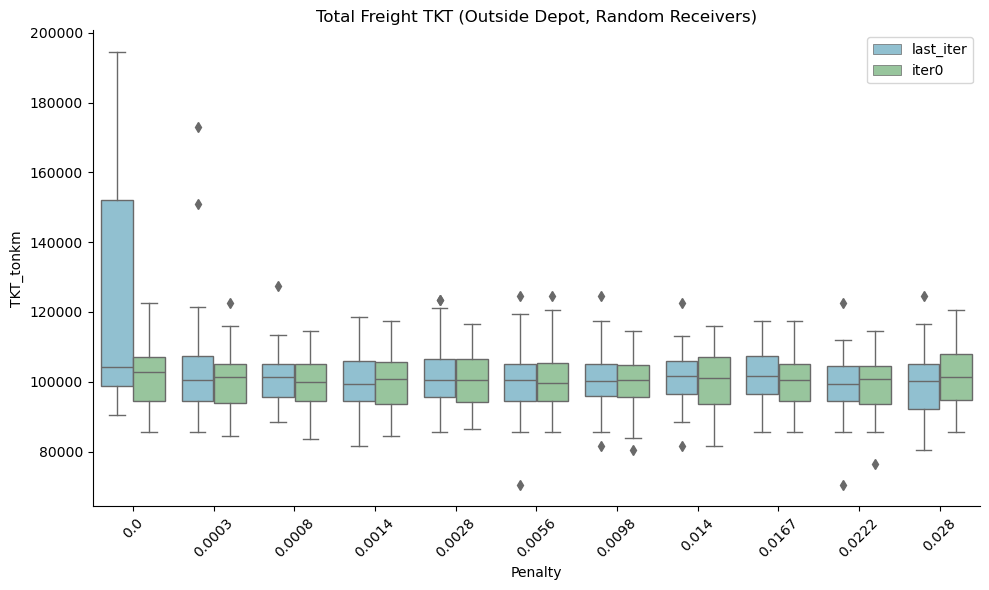

In [159]:
boxplot_metric(all_metrics_center_random_df, 
               metric='TKT_tonkm', 
               title='Total Freight TKT (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='TKT_tonkm', 
                title='Total Freight TKT (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### Fleet size

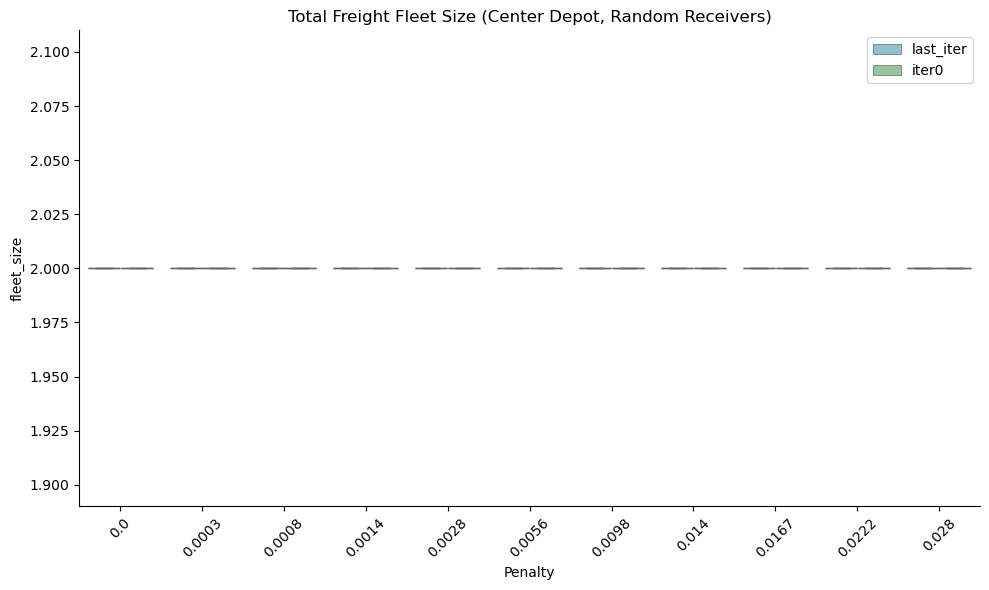

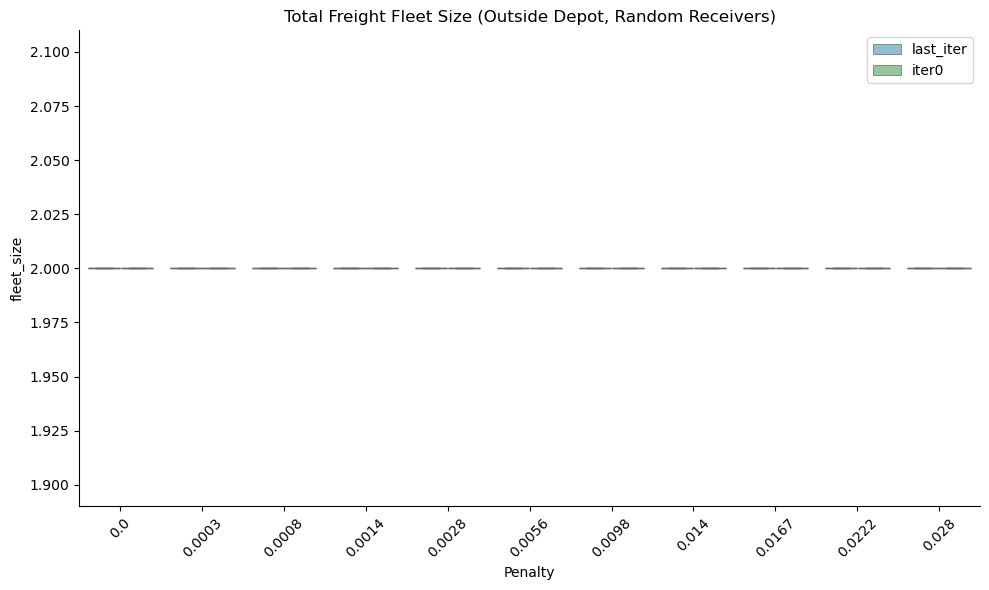

In [160]:
boxplot_metric(all_metrics_center_random_df, 
               metric='fleet_size', 
               title='Total Freight Fleet Size (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='fleet_size', 
                title='Total Freight Fleet Size (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### Carrier score

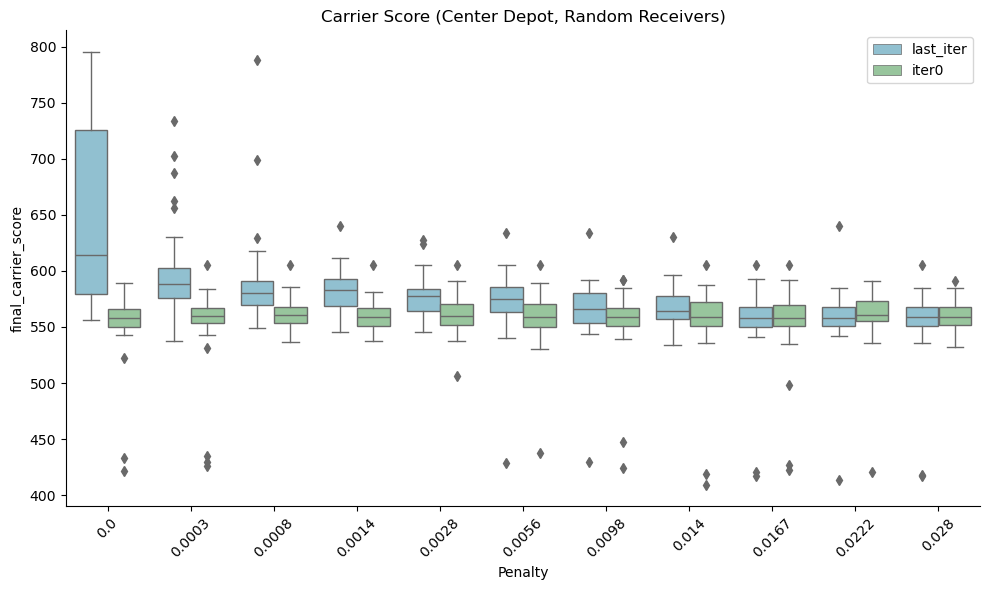

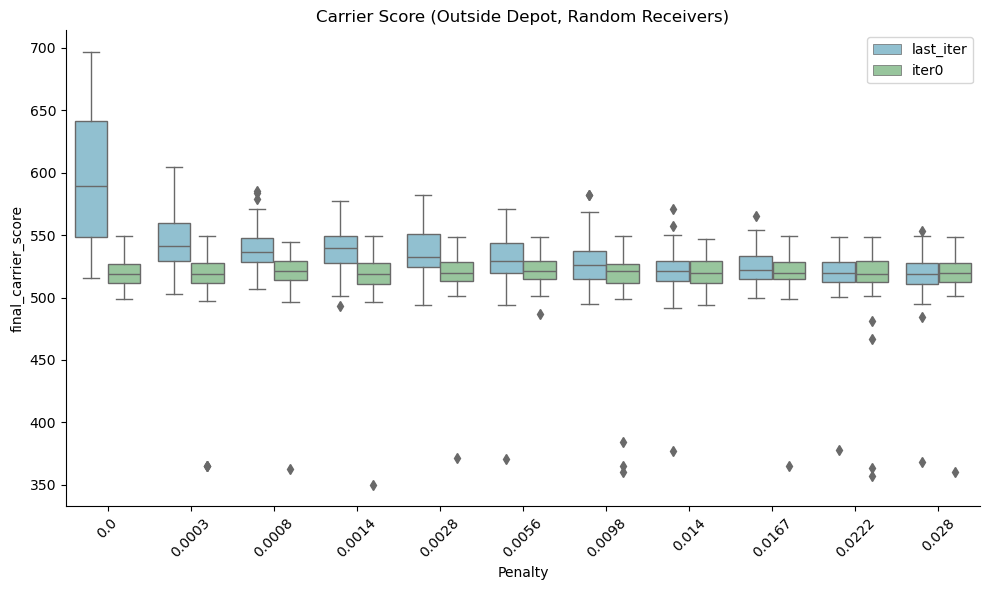

In [161]:
boxplot_metric(all_metrics_center_random_df, 
               metric='final_carrier_score', 
               title='Carrier Score (Center Depot, Random Receivers)', 
               iter0_metric='iter0_carrier_score')
boxplot_metric(all_metrics_outside_random_df,
                metric='final_carrier_score', 
                title='Carrier Score (Outside Depot, Random Receivers)', 
                iter0_metric='iter0_carrier_score')

### Receiver score

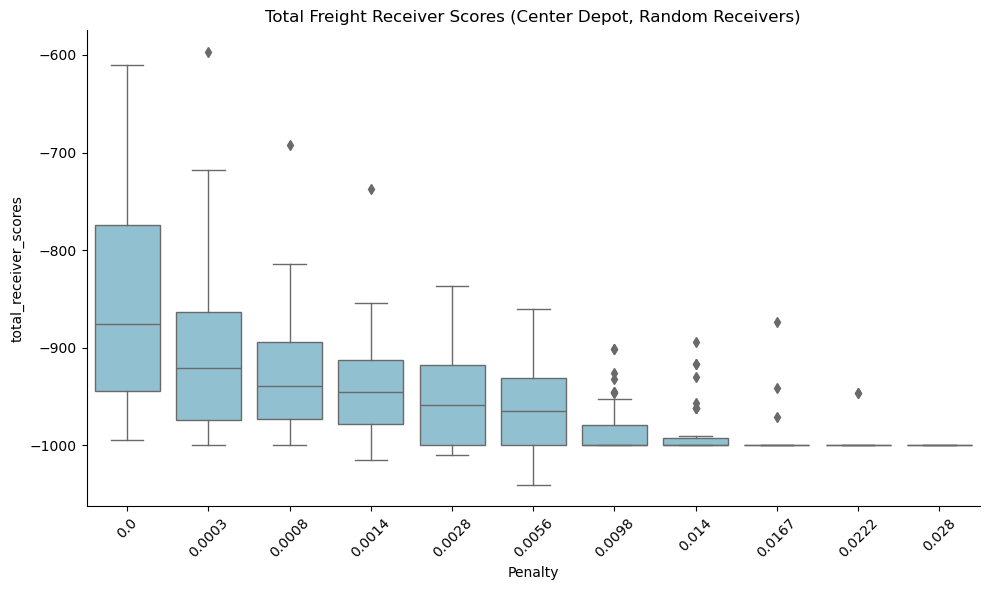

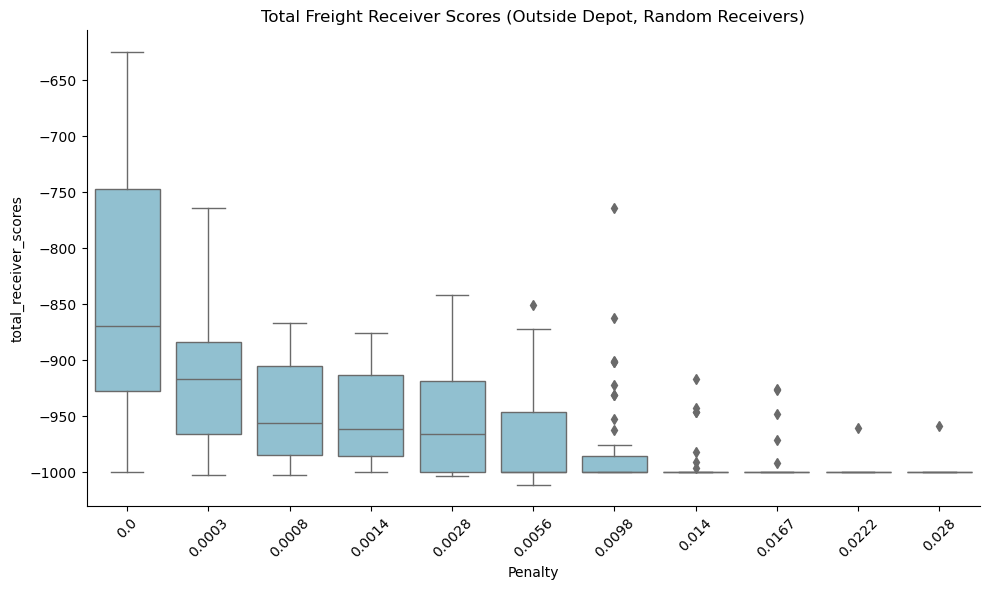

In [162]:
boxplot_metric(all_metrics_center_random_df, 
               metric='total_receiver_scores', 
               title='Total Freight Receiver Scores (Center Depot, Random Receivers)', 
               compare_iter0=False)
boxplot_metric(all_metrics_outside_random_df,
                metric='total_receiver_scores', 
                title='Total Freight Receiver Scores (Outside Depot, Random Receivers)', 
                compare_iter0=False)

### extended TWs

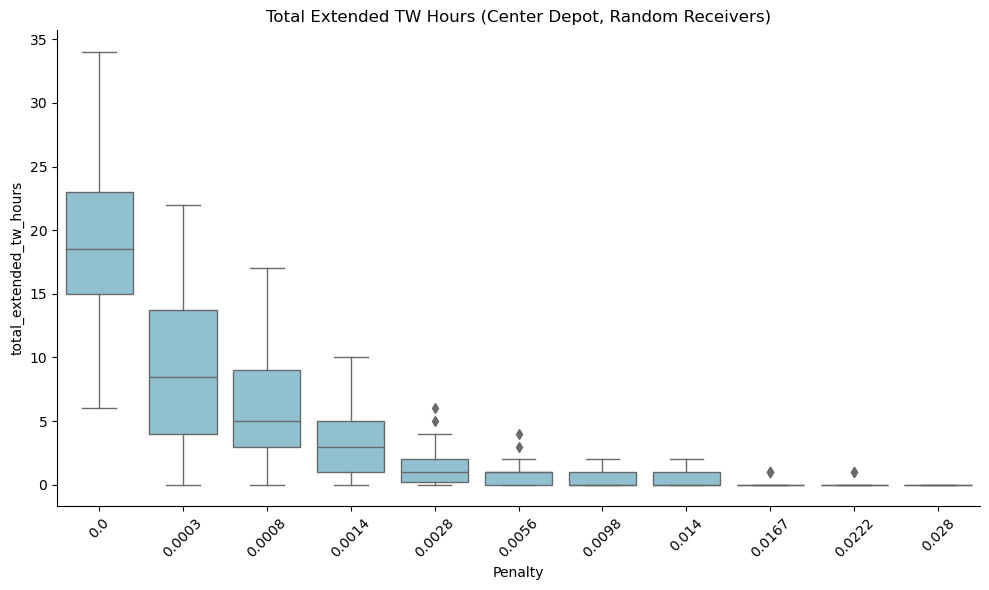

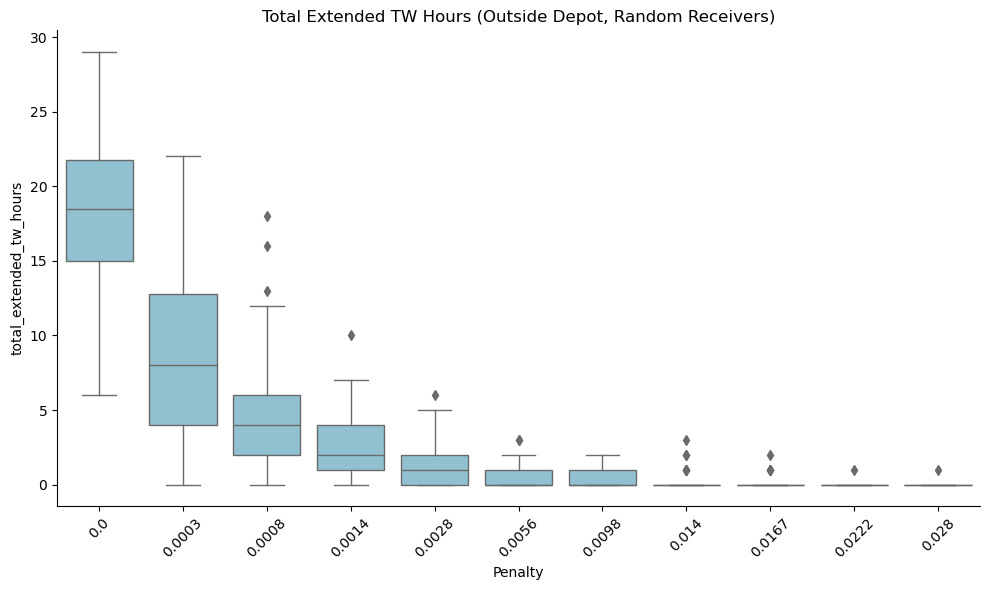

In [163]:
boxplot_metric(all_metrics_center_random_df, 
               metric='total_extended_tw_hours', 
               title='Total Extended TW Hours (Center Depot, Random Receivers)', 
               compare_iter0=False)
boxplot_metric(all_metrics_outside_random_df,
                metric='total_extended_tw_hours', 
                title='Total Extended TW Hours (Outside Depot, Random Receivers)', 
                compare_iter0=False)

### Mean receiver distance to the depot
This should be set as the X , exporing the correlations with other variables (like collaboration rate, scores, etc.)

In [ ]:
scatter_3d(all_metrics_center_random_df,
           x_col='mean_receiver_dist_to_depot_euclidean_km',
           y_col='collaboration_rate',
           z_col='penalty',
           color_col=None,
           title='center-random-Mean receiver euclidean dist to depot-collab rate-penalty'
           )
scatter_color_encoded(all_metrics_center_random_df,
                      x_col='mean_receiver_dist_to_depot_euclidean_km',
                      y_col='collaboration_rate',
                      z_color_col='penalty',
                      title='center-random-Mean receiver euclidean dist to depot-collab rate-penalty'
                      )
group_scatter_plot(all_metrics_center_random_df,
                   x_col='mean_receiver_dist_to_depot_euclidean_km',
                   y_col='collaboration_rate',
                   z_col='penalty',
                   group_of_z_col=[[0], [0.0003, 0.0008, 0.0014, 0.0028], [0.0056,
                        0.0098, 0.014], [0.0167, 0.0222, 0.028]],
                    group_labels=['None', 'low', 'medium', 'high']
                   )

In [ ]:
scatter_3d(all_metrics_center_random_df,
           x_col='mean_receiver_dist_to_depot_network_km',
           y_col='collaboration_rate',
           z_col='penalty',
           color_col=None,
           title='center-random-Mean receiver nx dist to depot-collab rate-penalty'
           )
scatter_color_encoded(all_metrics_center_random_df,
                      x_col='mean_receiver_dist_to_depot_network_km',
                      y_col='collaboration_rate',
                      z_color_col='penalty',
                      title='center-random-Mean receiver nx dist to depot-collab rate-penalty'
                      )
group_scatter_plot(all_metrics_center_random_df,
                   x_col='mean_receiver_dist_to_depot_network_km',
                   y_col='collaboration_rate',
                   z_col='penalty',
                   group_of_z_col=[[0], [0.0003, 0.0008, 0.0014, 0.0028], [0.0056,
                        0.0098, 0.014], [0.0167, 0.0222, 0.028]],
                    group_labels=['None', 'low', 'medium', 'high'],
                    
                   )

In [ ]:
scatter_3d(all_metrics_outside_random_df,
           x_col='mean_receiver_dist_to_depot_network_km',
           y_col='collaboration_rate',
           z_col='penalty',
           color_col=None,
           title='outside-random-Mean receiver nx dist to depot-collab rate-penalty'
           )
scatter_color_encoded(all_metrics_outside_random_df,
                      x_col='mean_receiver_dist_to_depot_network_km',
                      y_col='collaboration_rate',
                      z_color_col='penalty',
                      title='outside-random-Mean receiver nx dist to depot-collab rate-penalty'
                      )
group_scatter_plot(all_metrics_outside_random_df,
                   x_col='mean_receiver_dist_to_depot_network_km',
                   y_col='collaboration_rate',
                   z_col='penalty',
                   group_of_z_col=[[0], [0.0003, 0.0008, 0.0014, 0.0028], [0.0056,
                        0.0098, 0.014], [0.0167, 0.0222, 0.028]],
                    group_labels=['None', 'low', 'medium', 'high'],
                    title='outside-random-Mean receiver nx dist to depot-collab rate-penalty'
                   )
basic_scatter_plot(all_metrics_outside_random_df,
                     x_col='mean_receiver_dist_to_depot_network_km',
                     y_col='collaboration_rate',
                    #  penalty_value=0.0056,
                     title='outside-random-Mean receiver nx dist to depot-collab rate at penalty=0.0056'
                     )

## Analyse spatial scenarios

In [123]:
all_metrics_non_random_df.query("penalty > 0 and penalty <= 0.001 ").groupby(['instance'])['collaboration_rate'].agg('mean')

instance
0     0.2625
1     0.5625
2     0.3000
3     0.3500
4     0.3625
5     0.2000
6     0.3500
7     0.2000
8     0.1875
9     0.3500
10    0.3750
11    0.4875
12    0.2250
13    0.3500
14    0.5000
15    0.3125
16    0.4125
17    0.3625
18    0.3250
19    0.3375
20    0.1125
21    0.4750
22    0.5000
23    0.3125
24    0.2875
25    0.4500
26    0.2375
27    0.2625
28    0.4250
29    0.2250
30    0.2375
31    0.1375
32    0.3750
33    0.3250
34    0.4125
35    0.3750
36    0.4375
37    0.3250
38    0.4375
39    0.3000
40    0.2625
41    0.3375
42    0.3750
43    0.5625
44    0.4375
45    0.3125
46    0.5250
47    0.5375
48    0.3375
49    0.3625
Name: collaboration_rate, dtype: float64

In [114]:
all_metrics_center_dispersed_df.groupby(['instance'])['collaboration_rate'].agg('mean')

instance
0     0.227273
1     0.218182
2     0.272727
3     0.127273
4     0.163636
5     0.209091
6     0.209091
7     0.181818
8     0.290909
9     0.218182
10    0.263636
11    0.327273
12    0.209091
13    0.281818
14    0.309091
15    0.263636
16    0.345455
17    0.263636
18    0.236364
19    0.209091
20    0.145455
21    0.272727
22    0.281818
23    0.181818
24    0.218182
25    0.427273
26    0.190909
27    0.209091
28    0.327273
29    0.209091
30    0.445455
31    0.100000
32    0.209091
33    0.209091
34    0.281818
35    0.281818
36    0.318182
37    0.272727
38    0.245455
39    0.227273
40    0.354545
41    0.381818
42    0.481818
43    0.281818
44    0.381818
45    0.254545
46    0.263636
47    0.381818
48    0.163636
49    0.318182
Name: collaboration_rate, dtype: float64

In [115]:
all_metrics_center_clustered_df.groupby(['instance'])['collaboration_rate'].agg('mean')

instance
0     0.136364
1     0.300000
2     0.190909
3     0.163636
4     0.172727
5     0.109091
6     0.063636
7     0.172727
8     0.109091
9     0.190909
10    0.145455
11    0.118182
12    0.118182
13    0.063636
14    0.227273
15    0.054545
16    0.263636
17    0.363636
18    0.081818
19    0.227273
20    0.136364
21    0.200000
22    0.063636
23    0.181818
24    0.145455
25    0.081818
26    0.209091
27    0.063636
28    0.090909
29    0.136364
30    0.081818
31    0.081818
32    0.154545
33    0.154545
34    0.172727
35    0.118182
36    0.209091
37    0.181818
38    0.136364
39    0.090909
40    0.118182
41    0.090909
42    0.081818
43    0.245455
44    0.163636
45    0.172727
46    0.254545
47    0.063636
48    0.218182
49    0.063636
Name: collaboration_rate, dtype: float64

### collaboration rate

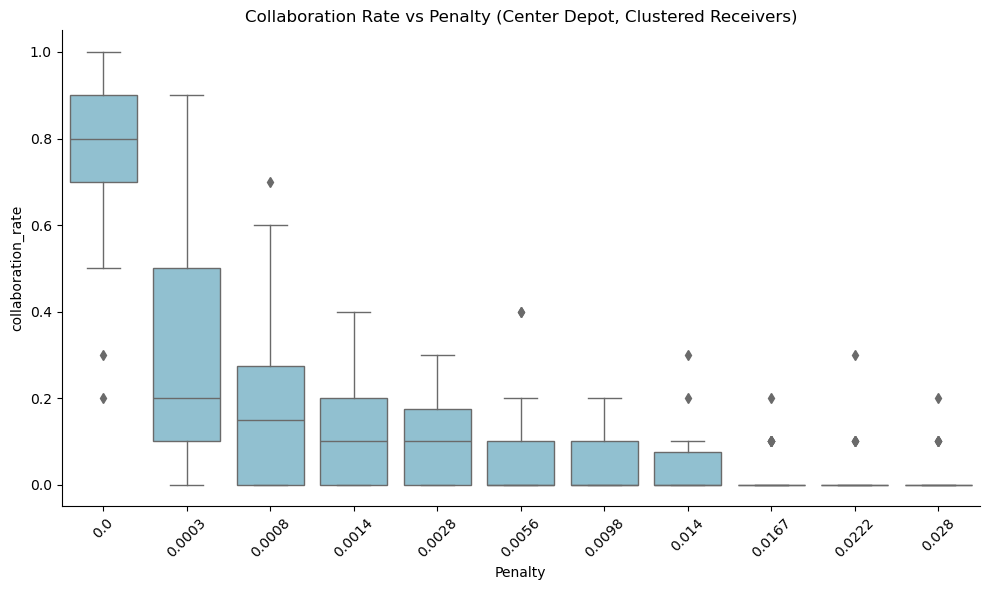

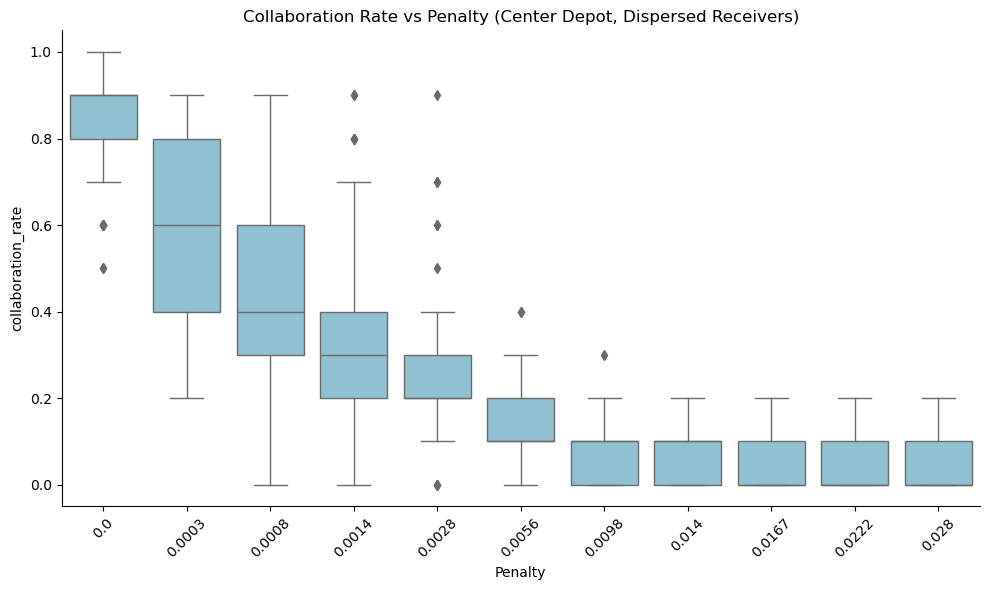

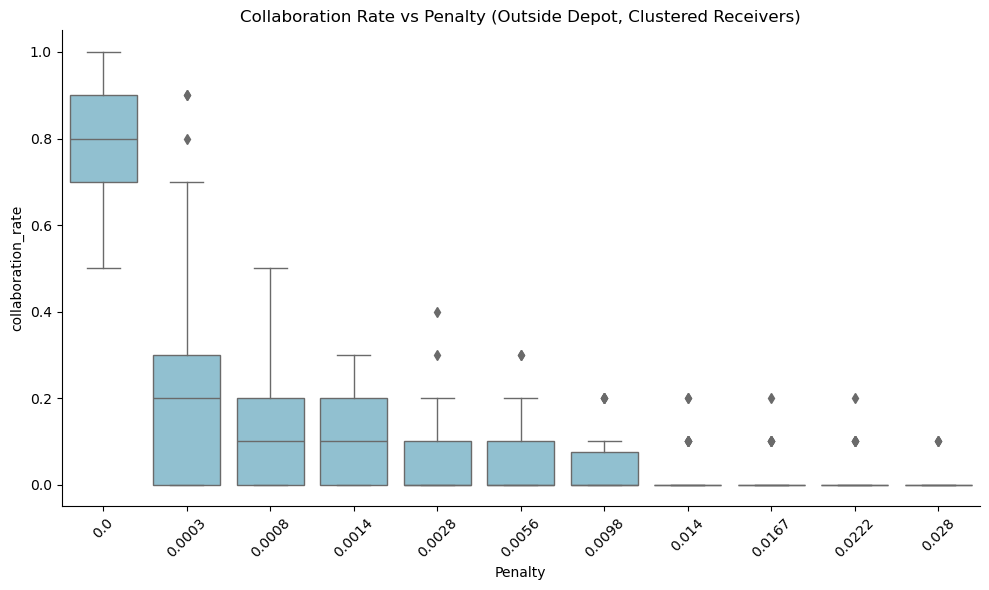

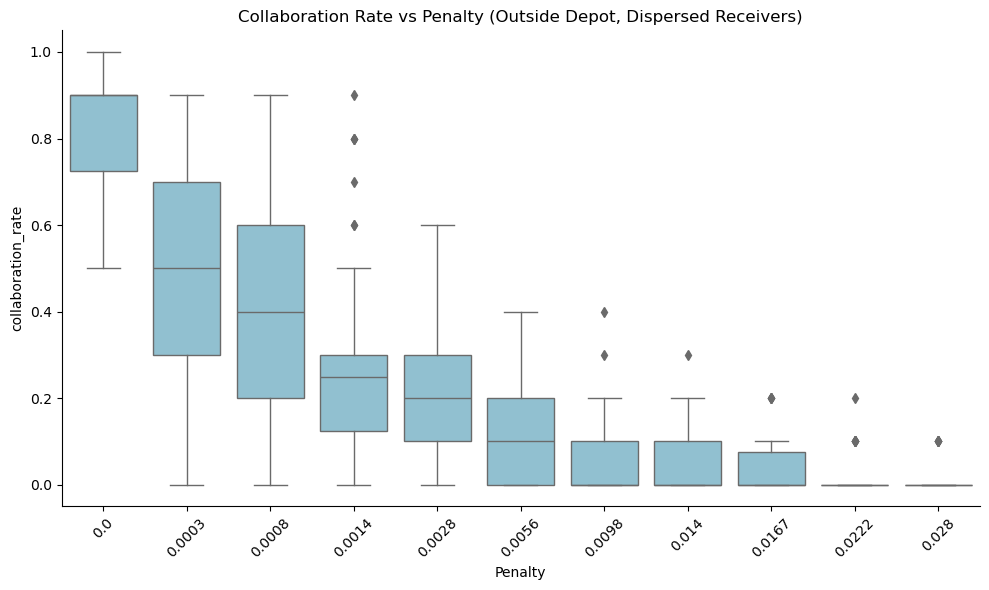

In [126]:
boxplot_metric(all_metrics_center_clustered_df,
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Clustered Receivers)',  
                compare_iter0=False)
boxplot_metric(all_metrics_center_dispersed_df,
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Dispersed Receivers)',  
                compare_iter0=False)
boxplot_metric(all_metrics_outside_clustered_df,
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Outside Depot, Clustered Receivers)',  
                compare_iter0=False)
boxplot_metric(all_metrics_outside_dispersed_df,
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Outside Depot, Dispersed Receivers)',  
                compare_iter0=False)

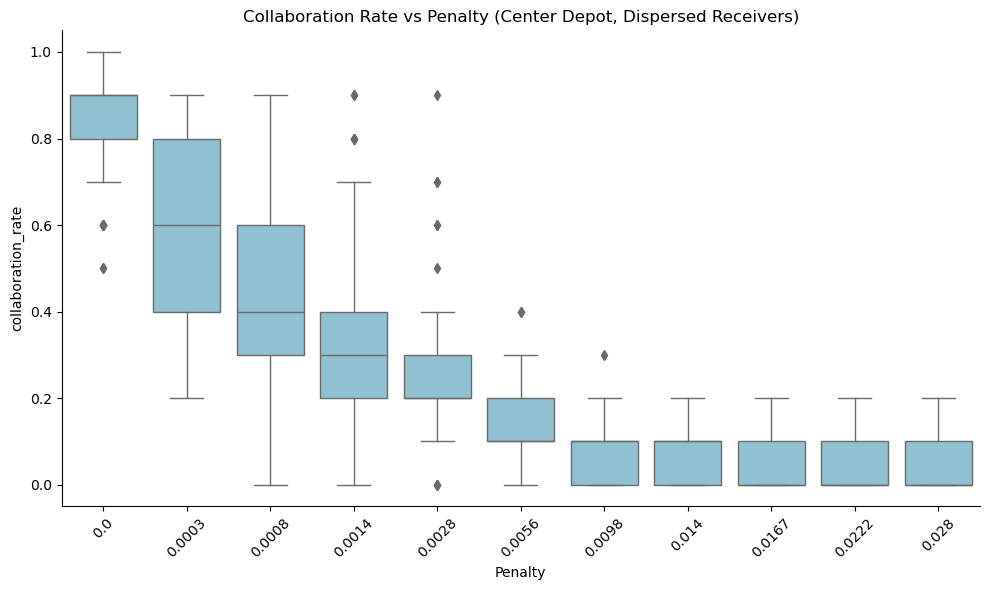

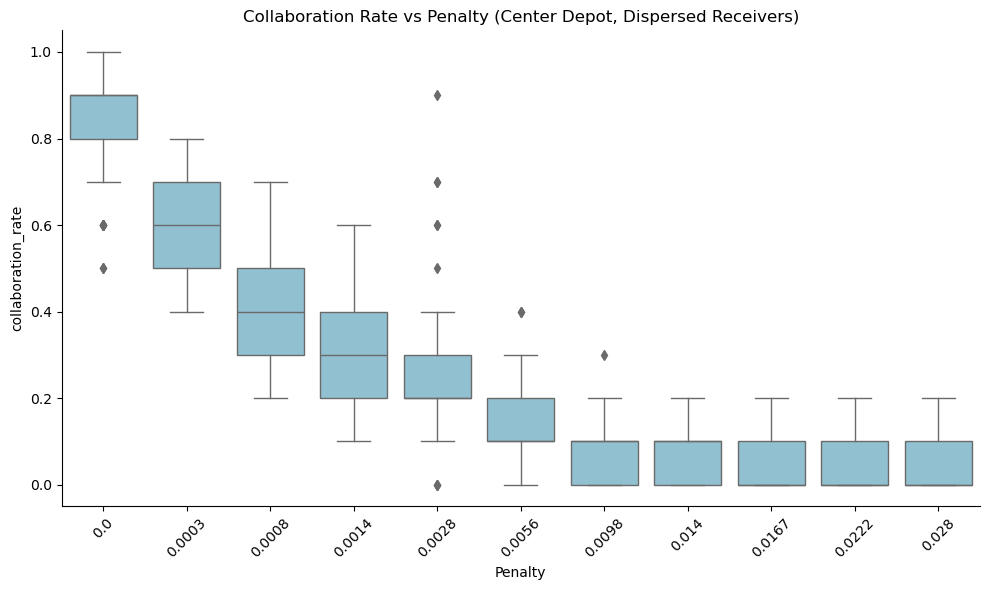

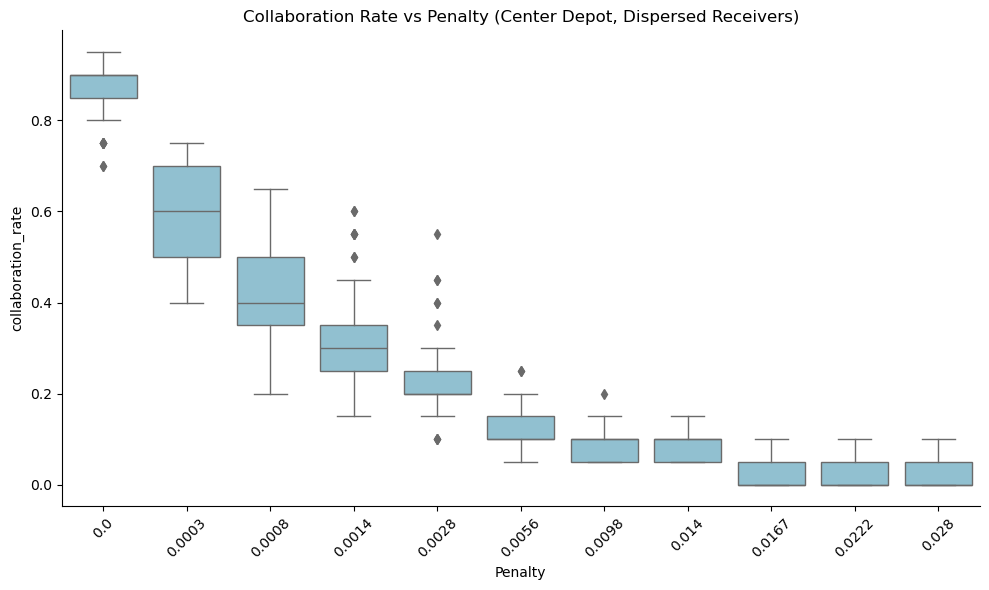

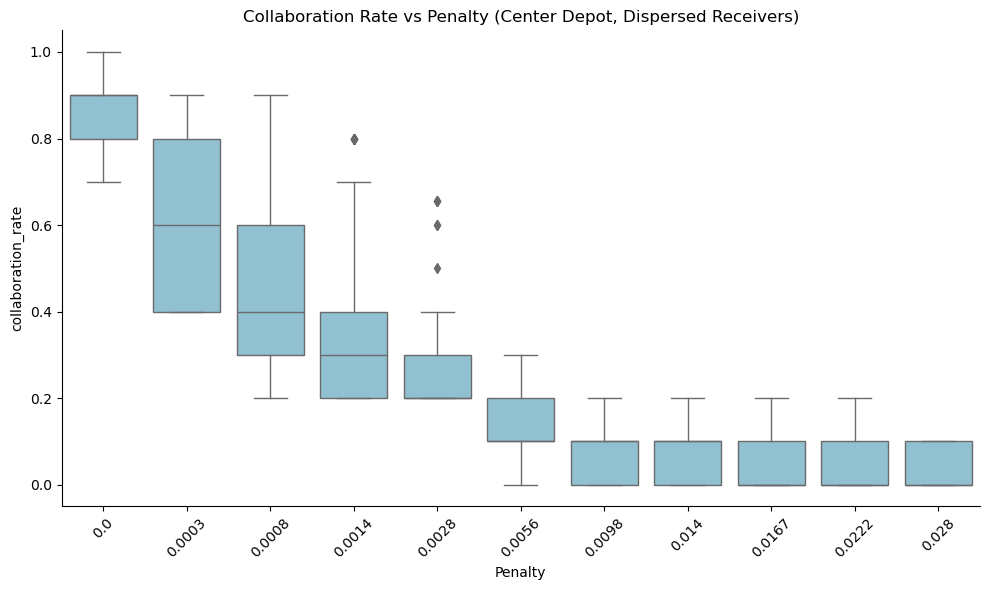

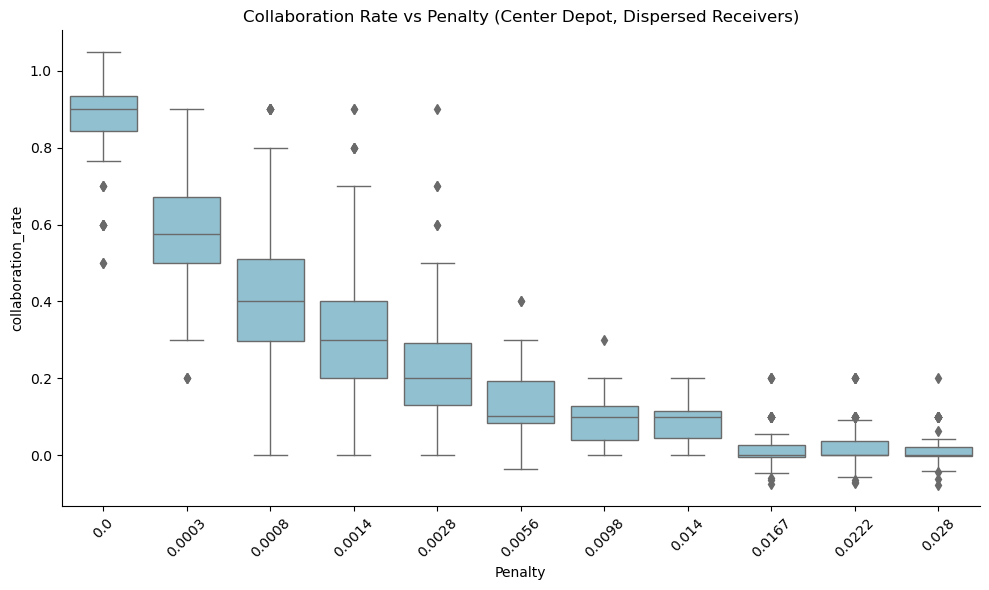

In [148]:
boxplot_metric(all_metrics_center_dispersed_df,
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Dispersed Receivers)',  
                compare_iter0=False)
boxplot_metric(shrink_group_variance(all_metrics_center_dispersed_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     value_step=0.1,
                                     alpha=0.55,
                                     groups=[0.0003, 0.0008, 0.0014]),
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Dispersed Receivers)',  
                compare_iter0=False)
#---This one outperforms the other two methods---#
boxplot_metric(shrink_group_variance(all_metrics_center_dispersed_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     alpha=0.5,
                                    #  groups=[0.0003, 0.0008]
                                     ),
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Dispersed Receivers)',  
                compare_iter0=False)
boxplot_metric(winsorize_group_values(all_metrics_center_dispersed_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     lower_q=0.2,
                                     upper_q=0.95,
                                    #  groups=[0.0003, 0.0008]
                                     ),
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Dispersed Receivers)',  
                compare_iter0=False)
boxplot_metric(augment_group_gaussian(all_metrics_center_dispersed_df,
                                     group_col='penalty',
                                     value_col='collaboration_rate',
                                     n_samples=50,
                                     noise_scale=0.5,
                                    #  groups=[0.0003, 0.0008]
                                     ),
                metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Dispersed Receivers)',  
                compare_iter0=False)